In [ ]:
!pip install himalaya
!pip install transformers
!pip install torchmetrics
!pip install fasttext
!pip install nilearn

# IF CPU
!TORCH_CUDA_ARCH_LIST="Pascal;Volta;Turing;Ampere" pip install torchsort
# IF GPU
!pip install torchsort

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import nibabel as nib
import numpy as np
from himalaya.ridge import GroupRidgeCV
from sklearn.model_selection import KFold
from scipy.stats import pearsonr
from scipy.stats import zscore
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import make_scorer
from himalaya.scoring import correlation_score,correlation_score_split
import pandas as pd
import tqdm

from transformers import BertTokenizer, BertModel, Trainer
from torch import nn
import fasttext
import torch
import random
import torch
import torchsort
from sklearn.preprocessing import normalize
from sklearn.utils import shuffle

import sys
sys.path.append('/content/drive/MyDrive/reviews')
import rsa_utils

import os
import sys

import torch.optim as optim


ModuleNotFoundError: No module named 'himalaya'

In [ ]:
from torchmetrics.functional import pairwise_cosine_similarity

def sim_matrix(a, b, eps=1e-8):
  # Given that cos_sim(u, v) = dot(u, v) / (norm(u) * norm(v))
  #                          = dot(u / norm(u), v / norm(v))
  # We fist normalize the rows, before computing their dot products via transposition:
  a_norm = a / a.norm(dim=1)[:, None]
  b_norm = b / b.norm(dim=1)[:, None]
  res = torch.mm(a_norm, b_norm.transpose(0,1))
  return res



def spearmanr(pred, target, **kw):
    pred = torchsort.soft_rank(pred, **kw)
    target = torchsort.soft_rank(target, **kw)
    pred = pred - pred.mean()
    pred = pred / pred.norm()
    target = target - target.mean()
    target = target / target.norm()
    return (pred * target).sum()

pred = torch.tensor([[1., 2., 3., 4., 5.]], requires_grad=True)
target = torch.tensor([[5., 6., 7., 8., 7.]])
spearman = spearmanr(pred, target)
# tensor(0.8321)

torch.autograd.grad(spearman, pred)
# (tensor([[-5.5470e-02,  2.9802e-09,  5.5470e-02,  1.1094e-01, -1.1094e-01]]),)

(tensor([[-5.5470e-02,  2.9802e-09,  5.5470e-02,  1.1094e-01, -1.1094e-01]]),)

In [ ]:
from transformers import PreTrainedModel, AutoModel, AutoConfig, AutoTokenizer

class RegressionTransformer(PreTrainedModel):

    def __init__(self, config):
        super().__init__(config)

        self.transformer = AutoModel.from_config(config)
        self.get_cls = lambda x: x.last_hidden_state[:, 0, :]
        self.sentence_linear = nn.Linear(config.hidden_size, config.sentence_embedding_size)
        self.linear = nn.Linear(config.sentence_embedding_size * 2, 1)


    def forward(self, input_ids, attention_mask=None, token_type_ids=None, position_ids=None, labels=None):
        transformer_output = self.transformer(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, position_ids=position_ids)
        # transformer_hidden = transformer_output.last_hidden_state
        # self.cls_hidden = transformer_hidden[:, 0, :]

        # prediction = self.linear(self.get_cls(transformer_output))
        sep_locs = [torch.argwhere(token_span==102) for token_span in input_ids]

        reps = self.transformer(input_ids, attention_mask=attention_mask).last_hidden_state

        sentence_one_reps = torch.stack([rep[1:sep_loc[0], :].float().mean(axis=0) for (sep_loc, rep) in zip(sep_locs, reps)])
        sentence_two_reps = torch.stack([rep[sep_loc[0]+1:sep_loc[1], :].float().mean(axis=0) for (sep_loc, rep) in zip(sep_locs, reps)])

        # stacked_sentences = torch.hstack([self.sentence_linear(sentence_one_reps), self.sentence_linear(sentence_two_reps)])
        return torch.nn.CosineSimilarity()(self.sentence_linear(sentence_one_reps), self.sentence_linear(sentence_two_reps))

        # prediction = self.linear(stacked_sentences)

        # return prediction

    def regularization(self, x, Y_sim_matrix, attention_mask=None, min_corr=True):
      # def regularization(self, x, Y):
      # sep_locs = [torch.argwhere(token_span==102) for token_span in x]

      # # reps = self.transformer.encoder(self.transformer.embeddings(x)).last_hidden_state
      # reps = self.transformer(x, attention_mask=attention_mask).last_hidden_state
      # sentence_one_reps = torch.stack([rep[1:sep_loc[0], :].float().mean(axis=0) for (sep_loc, rep) in zip(sep_locs, reps)])
      # sentence_two_reps = torch.stack([rep[sep_loc[0]+1:sep_loc[1], :].float().mean(axis=0) for (sep_loc, rep) in zip(sep_locs, reps)])

      # rdm_x = torch.nn.CosineSimilarity()(sentence_one_reps, sentence_two_reps).reshape(1, -1)

      # # rdm_y = torch.triu(pairwise_cosine_similarity(Y, Y), diagonal=1)
      # # rdm_y = torch.triu(Y_sim_matrix, diagonal=1)
      # rdm_y = Y_sim_matrix
      # # rdm_y = torch.triu(Y_sim_matrix, diagonal=1)
      # return 1 - spearmanr(rdm_x, rdm_y)

      transformer_output = self.transformer(x, attention_mask=attention_mask, token_type_ids=None, position_ids=None)
      sep_locs = [torch.argwhere(token_span==102) for token_span in x]
      reps = self.transformer(x, attention_mask=attention_mask).last_hidden_state

      sentence_one_reps = torch.stack([rep[1:sep_loc[0], :].float().mean(axis=0) for (sep_loc, rep) in zip(sep_locs, reps)])
      sentence_two_reps = torch.stack([rep[sep_loc[0]+1:sep_loc[1], :].float().mean(axis=0) for (sep_loc, rep) in zip(sep_locs, reps)])

      sentence_one_reps = self.sentence_linear(sentence_one_reps)
      sentence_two_reps = self.sentence_linear(sentence_two_reps)

      rdm_x = torch.nn.CosineSimilarity()(sentence_one_reps, sentence_two_reps).reshape(1, -1)

      rdm_y = Y_sim_matrix

      return 1 - spearmanr(rdm_x, rdm_y)



In [ ]:
# x= X_train_per_batch[0]
# Y_sim_matrix = brain_sim_per_batch[0].reshape(1, -1)

# sep_locs = [torch.argwhere(token_span==102) for token_span in x]

# reps = model.transformer.encoder(model.transformer.embeddings(x)).last_hidden_state

# sentence_one_reps = torch.stack([rep[1:sep_loc[0], :].float().mean(axis=0) for (sep_loc, rep) in zip(sep_locs, reps)])
# sentence_two_reps = torch.stack([rep[sep_loc[0]+1:sep_loc[1], :].float().mean(axis=0) for (sep_loc, rep) in zip(sep_locs, reps)])

# rdm_x = torch.nn.CosineSimilarity()(sentence_one_reps, sentence_two_reps).reshape(1, -1)

# rdm_y = Y_sim_matrix

# 1 - spearmanr(rdm_x, rdm_y)

In [ ]:
model_name = "textattack/bert-base-uncased-STS-B"
config = AutoConfig.from_pretrained(model_name)
config.sentence_embedding_size = 50
model = RegressionTransformer(config)
tokenizer = AutoTokenizer.from_pretrained("textattack/bert-base-uncased-STS-B")

In [ ]:
model

RegressionTransformer(
  (transformer): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, 

In [ ]:
# STS-b (bert-base-uncased-stsb)

#     datasets dataset glue, subset stsb, split validation

#     Pearson correlation: 0.8775458937815515

#     Spearman correlation: 0.8773251339980935



In [ ]:
from scipy.spatial.distance import cosine

In [ ]:
# Loading embeddings and inputs

df = pd.read_csv('/content/drive/MyDrive/bert-brains/embeddings.csv')
df['ada_embedding'] = df.ada_embedding.apply(eval).apply(np.array)
df['tr'] = range(df.shape[0])

dist_rows_df = pd.read_csv('/content/drive/MyDrive/bert-brains/dist_rows_df.csv') # Pairwise embedding distance
dist_rows_df['sim'] = 1 - dist_rows_df['dist']

In [ ]:
dist_rows_df.sim.mean()

0.7696467102175067

In [ ]:
all_inds = list(range(df.shape[0]))

begin_delay = 18
new_inds = all_inds[begin_delay:1205][:601] # splice1
new_inds=new_inds[10:-10]

map_new_inds_to_old = {x: i for i, x in enumerate(new_inds)}
map_old_inds_to_new = {i: x for i, x in enumerate(new_inds)}

def filter_to_new_inds(arr):
  return arr[:601][10:-10]

len(new_inds)

581

In [ ]:
# training parameters
batch_size = 10

In [ ]:
sentences = df.text.tolist()
sentences = filter_to_new_inds(sentences)
sentences = np.array(sentences)

num_sentences = len(sentences)

train_split = 2/3
num_train = int(num_sentences * train_split)
print(num_train)

test_start = num_train + 20 # Prevent overlap

387


In [ ]:
# with tqdm.trange(batches_per_epoch, unit="batch", mininterval=0) as bar:
#     bar.set_description(f"Epoch {epoch}, MSE Loss: {loss.round(decimals=2)}")
#     for i in bar:
#         # take a batch
#         start = i * batch_size
#         X_batch = X_train_ids[start:start+batch_size]
#         Y_batch = Y_train_sim[start:start+batch_size]

In [ ]:
# pd.read_csv('/root/nilearn_data/destrieux_2009/destrieux2009_rois_labels_lateralized.csv')

In [ ]:
from nilearn import datasets

dataset = datasets.fetch_atlas_destrieux_2009()
atlas_filename = dataset.maps
labels = dataset.labels


# print(f"Atlas ROIs are located in nifti image (4D) at: {atlas_filename}")

# # One subject of brain development fmri data
# data = datasets.fetch_development_fmri(n_subjects=1, reduce_confounds=True)
# fmri_filenames = data.func[0]
# reduced_confounds = data.confounds[0]  # This is a preselected set of confounds

# nii=nib.load(data_dir+sub+".nii.gz")
# img = nii.slicer[:,:,:,begin_delay:1205].slicer[:,:,:,10:-10]

# from nilearn.maskers import NiftiLabelsMasker

# masker = NiftiLabelsMasker(
#     labels_img=atlas_filename,
#     standardize="zscore_sample",
#     standardize_confounds="zscore_sample",
#     memory="nilearn_cache",
#     verbose=5,
# )

# # Here we go from nifti files to the signal time series in a numpy
# # array. Note how we give confounds to be regressed out during signal
# # extraction
# time_series = masker.fit_transform(img)

# np.savetxt('/content/drive/MyDrive/bert-brains/time_series.numpy', time_series)

time_series = np.loadtxt('/content/drive/MyDrive/bert-brains/time_series.numpy')


In [ ]:
all_subject_ids = [x.split('.')[0] for x in os.listdir('/content/drive/MyDrive/bert-brains/slumlordreach_data/') if x.endswith('nii.gz') and len(x) < 15]

In [ ]:
def ffill_array(arr):
  arr2=arr.copy().astype('float')
  arr2[np.sum(arr,axis=1)==0]=np.nan
  df=pd.DataFrame(arr2)
  df2=df.ffill()
  return df2.to_numpy()

def get_brain_data(subject_id='143'):
  base_dir = '/content/drive/MyDrive/bert-brains/'

  story_name = 'slumlordreach'
  model = 'bert-base-uncased'
  layer_dir=base_dir + 'data/slumlordreach/bert-base-uncased/raw_embeddings/slumlordreach_bert-base-uncased_layer_11_activations.npy'
  layer_name='slumlordreach_bert-base-uncased_layer_11_activations'
  data_dir=base_dir + 'slumlordreach_data/'
  begin_trim="15"
  end_trim="2240"
  save_dir=base_dir + 'PhD/bert-brains/output/'

  zero_intercept=False


  nii=nib.load(data_dir+subject_id+".nii.gz")
  affine_mat = nii.affine  # What is the data transformation used here

  data_prefix=base_dir + 'slumlordreach_data/'
  phoneme_counts=np.load(data_prefix+"slumlordreach_phoneme_counts.npy").reshape((-1,1))
  word_counts=np.load(data_prefix+"slumlordreach_word_counts.npy").reshape((-1,1))
  phoneme_vectors=np.load(data_prefix+"slumlordreach_phoneme_vectors.npy")
  silent=((phoneme_counts[:,0]==0).astype('int')).reshape((-1,1))
  primary_features=np.hstack([phoneme_vectors,phoneme_counts,word_counts,silent])

  #primary_features=np.hstack([phoneme_counts,phoneme_vectors,word_counts])

  load_features=np.load(layer_dir,allow_pickle=True)
  if len(load_features.shape)==1:
      load_features=np.reshape(load_features,(-1,1))
  raw_features=[]
  raw_primary_features=[]
  raw_silent_features=[]
  for i in range(load_features.shape[0]):
      if load_features[i] is not None and len(load_features[i])>0 and load_features[i][0] is not None:
          raw_primary_features.append(primary_features[i])
          raw_silent_features.append(silent[i])
          if 'semantic_composition' in layer_dir or 'syntactic_complexity' in layer_dir:
              raw_features.append(np.asarray(load_features[i][0]))
          else:
              raw_features.append(load_features[i])
  raw_features=np.vstack(raw_features)
  raw_primary_features=np.vstack(raw_primary_features)
  raw_silent_features=np.vstack(raw_silent_features)
  #raw_features[raw_silent_features[:,0]==1]=0

  #raw_features=ffill_array(raw_features)
  raw_features[raw_silent_features[:,0].astype('bool')]=0.0

  num_primary=primary_features.shape[1]

  raw_features=np.hstack([raw_features,raw_primary_features])


  shifted=[]
  is_primary_lst=[]
  shifted_silent=[]
  delays=[2,3,4,5]
  for d in delays:
      arr=np.zeros((raw_features.shape[0]+5,raw_features.shape[1]))
      arr_prim=np.zeros(arr.shape)
      arr_prim[:,-num_primary:]=1
      arr[d:raw_features.shape[0]+d,:]=raw_features
      is_primary_lst.append(arr_prim)
      shifted.append(arr)

      arr_shifted=np.zeros((raw_silent_features.shape[0]+5,raw_silent_features.shape[1]))
      arr_shifted[d:raw_silent_features.shape[0]+d,:]=raw_silent_features
      shifted_silent.append(arr_shifted)

  features=np.hstack(shifted)
  is_primary=np.hstack(is_primary_lst)
  silent_features=np.hstack(shifted_silent)

  begin_delay=3+(1192-raw_features.shape[0])

  splice1=619-begin_delay
  splice2=644-begin_delay

  load_data=nii.get_fdata()[:,:,:,begin_delay:1205]

  #load_data=np.concatenate([zscore(load_data[:,:,:,:splice1],axis=3,ddof=1),zscore(load_data[:,:,:,splice2:],axis=3,ddof=1)],axis=3)
  #load_data[np.isnan(load_data)]=0.0
  #features=np.concatenate([features[:splice1,:],features[splice2:,:]],axis=0)
  #is_primary=np.concatenate([is_primary[:splice1,:],is_primary[splice2:,:]],axis=0)
  #print(load_data.shape)
  load_data=zscore(load_data[:,:,:,:splice1],axis=3,ddof=1)
  #print(load_data.shape)
  load_data[np.isnan(load_data)]=0.0
  #print(load_data.shape)
  features=features[:splice1,:]
  is_primary=is_primary[:splice1,:]
  silent_features=silent_features[:splice1,:]

  features=features[10:-10,:]
  is_primary=is_primary[10:-10,:]
  raw_data=load_data[:,:,:,10:-10]
  silent_features=silent_features[10:-10,:]

  #include=(np.sum(silent_features,axis=1)==0).astype('bool')
  #features=features[include]
  #is_primary=is_primary[include]
  #raw_data=raw_data[:,:,:,include]
  print(raw_data.shape,features.shape)

  trailing=raw_data.shape[3]-features.shape[0]
  if trailing>0:
      raw_data=raw_data[:,:,:,:-trailing]


  assert raw_data.shape[3]==features.shape[0]
  assert is_primary.shape==features.shape
  row_equivalence=True
  for row in is_primary:
      if np.sum(row!=is_primary[0])>0:
          row_equivalence=False
  assert row_equivalence

  val_size=70

  #features=np.asarray([np.hstack([raw_features[tr+2],raw_features[tr+3],raw_features[tr+4],raw_features[tr+5]]) for tr in range(raw_features.shape[0]-5)])
  #features=np.asarray([raw_features[tr+3] for tr in range(raw_features.shape[0]-3)])
  #data = nii.get_fdata()[:,:,:,begin_trim:end_trim-3]
  parcellation_nii=nib.load(data_dir+"Schaefer1000_3mm.nii.gz")
  affine=parcellation_nii.affine
  parcellation=parcellation_nii.get_fdata().astype('int')
  num_parcels=1000
  data=np.zeros((num_parcels,raw_data.shape[-1]))

  for p in range(num_parcels):
    data[p,:]=raw_data[np.where(parcellation==p+1)].mean(axis=0)


  exponents=list(range(-25,26,2))
  alphas=[10**e for e in exponents]

  is_primary_features=is_primary[0,:].astype('bool')
  X=features[:,~is_primary_features]
  X0_full=features[:,is_primary_features]

  is_silent_features=np.zeros(X0_full.shape[1])
  is_silent_features[42]=1
  is_silent_features[42+43]=1
  is_silent_features[42+43*2]=1
  is_silent_features[42+43*3]=1

  is_number_features=np.zeros(X0_full.shape[1])
  is_number_features[41]=1
  is_number_features[40]=1
  is_number_features[41+43]=1
  is_number_features[41+43*2]=1
  is_number_features[41+43*3]=1
  is_number_features[40+43]=1
  is_number_features[40+43*2]=1
  is_number_features[40+43*3]=1

  is_phoneme_features=np.zeros(X0_full.shape[1])
  for i in range(is_phoneme_features.shape[0]):
    if is_number_features[i]==0 and is_silent_features[i]==0:
      is_phoneme_features[i]=1


  is_silent_features=is_silent_features.astype('bool')
  is_number_features=is_number_features.astype('bool')
  is_phoneme_features=is_phoneme_features.astype('bool')


  X0=X0_full[:,is_silent_features]
  X1=X0_full[:,is_number_features]
  X2=X0_full[:,is_phoneme_features]

  Y=data.T

  skf_outer=KFold(n_splits=3,shuffle=False)
  skf_inner=KFold(n_splits=3,shuffle=False)
  performances=np.zeros((1000,3,4))
  test_idx=0

  alphas=np.zeros((1000,3,4))

  weights=[]

  return Y

In [ ]:
import pickle

load_brain = True

if load_brain:
  with open('/content/drive/MyDrive/bert-brains/brain_dict.pkl', 'rb') as handle:
    subject_brain_dict = pickle.load(handle)

else:
  subject_brain_dict = {}

  for subject_id in tqdm.tqdm(all_subject_ids):
    subject_brain_dict[subject_id] = get_brain_data(subject_id)

  with open('/content/drive/MyDrive/bert-brains/brain_dict.pkl', 'wb') as handle:
      pickle.dump(subject_brain_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
time_series = time_series[begin_delay:1205][:601][10:-10]

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
np.stack(df.ada_embedding.tolist())[28:609].shape

(581, 1536)

In [ ]:
gpt_embeddings_rdm = rsa_utils.get_rdm(np.stack(df.ada_embedding.tolist())[28:609])

In [ ]:
train_brain_keys = list(subject_brain_dict.keys())[:-2]
print(len(train_brain_keys))
test_brain_keys = list(subject_brain_dict.keys())[-2:]
print(len(test_brain_keys))

13
2


In [ ]:
Y = get_brain_data('143')

(65, 77, 49, 581) (581, 3244)


In [ ]:
# OLD

old_res_rows = []
for i in tqdm.tqdm(range(1000)):
  rdm = rsa_utils.get_rdm(Y[:, i].reshape(-1, 1))
  res = rsa_utils.correlate_rdms(rdm, gpt_embeddings_rdm)
  old_res_rows.append({'i': i, 'statistic': res.statistic, 'pvalue': res.pvalue})

100%|██████████| 1000/1000 [00:34<00:00, 28.70it/s]


In [ ]:
load_res_df = True

if load_res_df:
  res_df = pd.read_csv('/content/drive/MyDrive/bert-brains/res_df')
else:
  res_rows = []
  for i in tqdm.tqdm(range(1000)):
    for brain_i, brain_key in enumerate(train_brain_keys):
      rdm = rsa_utils.get_rdm(subject_brain_dict[brain_key][:, i].reshape(-1, 1))
      res = rsa_utils.correlate_rdms(rdm, gpt_embeddings_rdm)
      res_rows.append({'i': i, 'brain_key': brain_key, 'statistic': res.statistic, 'pvalue': res.pvalue})

  res_df = pd.DataFrame(res_rows)
  res_df.to_csv('/content/drive/MyDrive/bert-brains/res_df', index=False)


In [ ]:
old_res_rows_df = pd.DataFrame(old_res_rows)


In [ ]:
corr_inds = res_df.sort_values('statistic').i.tolist()[::-1]
old_corr_inds = old_res_rows_df.sort_values('statistic').i.tolist()[::-1]

In [ ]:
res_df.brain_key.unique()

array([ 16,  84, 106, 111, 132, 133, 134, 135, 137, 138, 139, 140, 141])

In [ ]:
subject_brain_dict['142']

array([[-4.43426527e-01, -6.69248830e-02, -3.39914808e-01, ...,
         2.71530876e-01,  6.03939835e-01, -9.80428578e-02],
       [-4.88261915e-01, -2.15853537e-01, -2.91315653e-01, ...,
         3.13759895e-01,  7.04368862e-01,  2.49572548e-01],
       [-2.75446245e-01, -1.66081988e-01,  9.07246554e-02, ...,
         6.78140767e-01,  3.49203309e-01, -1.66793839e-01],
       ...,
       [ 4.90835839e-02,  4.46489395e-01,  1.13436421e-01, ...,
        -8.98996513e-02, -3.54437559e-01, -1.85566292e-01],
       [ 2.60336707e-04,  2.27490449e-01,  2.83358863e-01, ...,
        -3.45412538e-01,  3.07781100e-01, -1.17204862e-02],
       [-1.73548231e-01,  3.70249940e-02,  4.81388221e-01, ...,
         2.90458564e-01,  3.04867387e-01, -8.75507149e-03]])

In [ ]:
res_df

,i,brain_key,statistic,pvalue
0,0,16,-0.020371,6.131613e-17
1,0,84,-0.002865,2.395124e-01
2,0,106,0.035515,3.620583e-48
3,0,111,-0.019993,2.259138e-16
4,0,132,0.050865,6.331033e-97
...,...,...,...,...
12995,999,137,-0.004755,5.095657e-02
12996,999,138,-0.026194,5.682373e-27
12997,999,139,-0.037829,2.067652e-54
12998,999,140,0.028937,1.499247e-32


In [ ]:
bk = 16

res_df[res_df.brain_key==bk].sort_values('statistic').i.tolist()[::-1]

[611,
 615,
 101,
 102,
 606,
 704,
 284,
 106,
 281,
 608,
 225,
 779,
 252,
 626,
 321,
 845,
 287,
 824,
 665,
 878,
 860,
 756,
 119,
 668,
 886,
 236,
 667,
 515,
 218,
 378,
 108,
 280,
 224,
 849,
 234,
 902,
 367,
 781,
 126,
 974,
 861,
 285,
 777,
 222,
 603,
 978,
 109,
 607,
 319,
 481,
 613,
 503,
 110,
 153,
 215,
 687,
 158,
 530,
 253,
 115,
 810,
 659,
 118,
 291,
 137,
 440,
 213,
 104,
 365,
 263,
 511,
 617,
 700,
 773,
 114,
 635,
 588,
 862,
 205,
 67,
 505,
 241,
 674,
 441,
 921,
 139,
 836,
 817,
 728,
 620,
 85,
 299,
 882,
 100,
 864,
 197,
 113,
 666,
 219,
 264,
 677,
 335,
 619,
 501,
 508,
 853,
 105,
 669,
 863,
 449,
 732,
 257,
 21,
 303,
 923,
 272,
 614,
 468,
 379,
 834,
 762,
 554,
 282,
 973,
 579,
 716,
 778,
 120,
 807,
 71,
 184,
 411,
 916,
 727,
 527,
 885,
 768,
 598,
 736,
 703,
 622,
 401,
 177,
 233,
 739,
 249,
 44,
 940,
 76,
 504,
 279,
 671,
 127,
 639,
 764,
 198,
 855,
 185,
 354,
 574,
 858,
 770,
 461,
 691,
 124,
 491,
 811,
 609

In [ ]:
corr_inds_dict.keys()

dict_keys(['016', '084', '106', '111', '132', '133', '134', '135', '137', '138', '139', '140', '141'])

In [ ]:
brain_keys

NameError: name 'brain_keys' is not defined

In [ ]:
corr_inds_dict = {}

for bk in train_brain_keys:
  inds = res_df[res_df.brain_key==int(bk)].sort_values('statistic').i.tolist()[::-1]

  corr_inds_dict[bk] = [x for x in inds if x != 0]

In [ ]:
load_res_df = True

if load_res_df:
  res_df_two = pd.read_csv('/content/drive/MyDrive/bert-brains/res_df_two')
else:
  res_rows_two= []

  for i in tqdm.tqdm(range(0, 1000)):
    # parcel_rdm = rsa_utils.get_rdm(Y[:, corr_inds[:i+1]].reshape(-1, i+1))
    for bk in train_brain_keys:
      rdm = rsa_utils.get_rdm(subject_brain_dict[bk][:, corr_inds_dict[bk][:i+1]].reshape(-1, i+1))

      res = rsa_utils.correlate_rdms(rdm, gpt_embeddings_rdm)
      res_rows_two.append({'i': i, 'brain_key': bk, 'statistic': res.statistic, 'pvalue': res.pvalue})

  res_df_two = pd.DataFrame(res_rows_two)
  res_df_two.to_csv('/content/drive/MyDrive/bert-brains/res_df_two', index=False)


In [ ]:
pearsonr([1231,3123,123,123], [123,451,521,311])

PearsonRResult(statistic=0.06079755532495682, pvalue=0.9392024446750431)

In [ ]:
comp_rows = []
for i in tqdm.tqdm(range(400)):
  old_corr_vector = np.zeros((Y.shape[-1]))
  new_corr_vector = np.zeros(Y.shape[-1])

  old_corr_vector[old_corr_inds[:i+1]] = 1
  new_corr_vector[corr_inds[:i+1]] = 1

  res = pearsonr(old_corr_vector, new_corr_vector)

  comp_rows.append({'i': i, 'statistic': res.statistic,
                    'pvalue': res.pvalue})

comp_rows_df = pd.DataFrame(comp_rows)

100%|██████████| 400/400 [00:00<00:00, 1024.55it/s]


In [ ]:
comp_rows_df

,i,statistic,pvalue
0,0,-1.001001e-03,0.974779
1,1,-2.004008e-03,0.949533
2,2,-3.009027e-03,0.924287
3,3,-4.016064e-03,0.899066
4,4,-5.025126e-03,0.873897
...,...,...,...
395,395,2.135556e-03,0.946225
396,396,3.361064e-03,0.915461
397,397,2.095345e-04,0.994720
398,398,-1.204313e-03,0.969659


In [ ]:
rdms = [rsa_utils.get_rdm(subject_brain_dict[x][:, corr_inds[:36+1]].reshape(-1, 36+1)) for x in train_brain_keys]
mean_rdm = np.mean(rdms, axis=0)

In [ ]:
len(train_brain_keys)

13

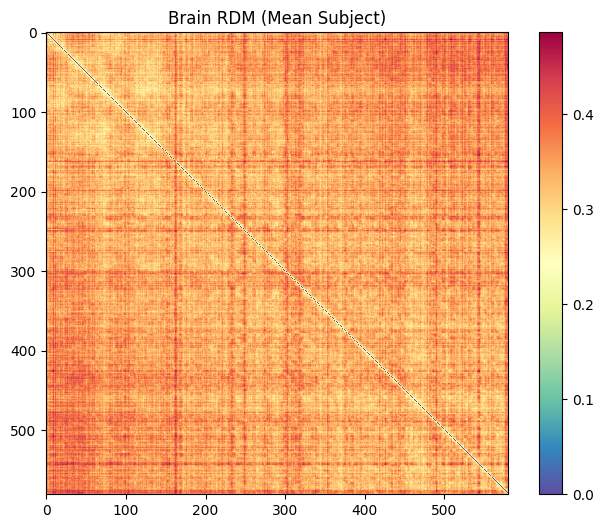

In [ ]:
rsa_utils.plot_mtx(mean_rdm, "Brain RDM (Mean Subject)")

In [ ]:
[rsa_utils.plot_mtx(x, "Brain RDM (Subject {})".format(y)) for y, x in zip(train_brain_keys[3:7], rdms[3:7])]

Text(0, 0.5, 'Correlation')

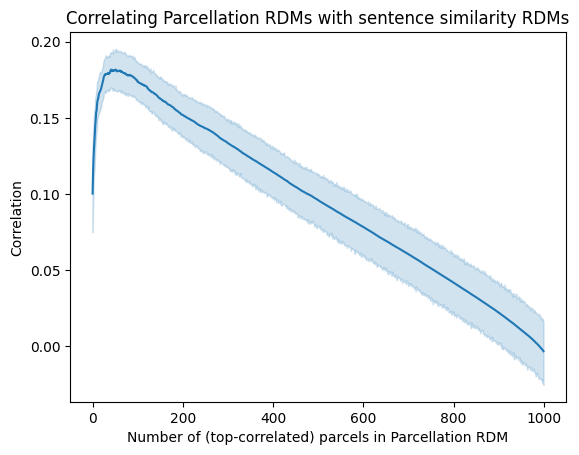

In [ ]:
import seaborn as sns

ax = sns.lineplot(data=res_df_two, x='i', y='statistic')
ax.set_title('Correlating Parcellation RDMs with sentence similarity RDMs')
ax.set_xlabel('Number of (top-correlated) parcels in Parcellation RDM')
ax.set_ylabel('Correlation')


Text(0, 0.5, 'Correlation')

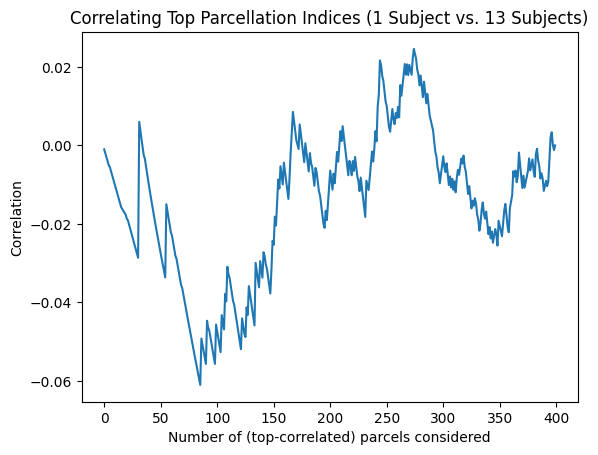

In [ ]:

ax = sns.lineplot(data=comp_rows_df, x='i', y='statistic')
ax.set_title('Correlating Top Parcellation Indices (1 Subject vs. 13 Subjects)')
ax.set_xlabel('Number of (top-correlated) parcels considered')
ax.set_ylabel('Correlation')


In [ ]:
[res_df_two[res_df_two.statistic==res_df_two.statistic.max()]]

[   i  brain_key  statistic  pvalue
 1  0         84   0.238639     0.0]

In [ ]:
res_df_two.sort_values('statistic', ascending=False)

,i,brain_key,statistic,pvalue
1,0,84,0.238639,0.0
14,1,84,0.236535,0.0
27,2,84,0.234745,0.0
53,4,84,0.233285,0.0
40,3,84,0.231615,0.0
...,...,...,...,...
12936,995,84,-0.095506,0.0
12949,996,84,-0.095984,0.0
12962,997,84,-0.096299,0.0
12975,998,84,-0.096891,0.0


In [ ]:
rsa_utils.correlate_rdms(rsa_utils.get_rdm(Y), gpt_embeddings_rdm)

SignificanceResult(statistic=-0.053955987390961684, pvalue=7.716166455555973e-109)

## Language Centre Parcellation

- **Angular gyrus**: *occupying the posterior part of the inferior parietal lobule*
- **Broca's area**: "*now typically defined in terms of the **pars opercularis** and **pars triangularis** of the inferior frontal gyrus*
- **Wernicke's area**: *"traditionally thought to reside in Brodmann area 22, which is located in the **superior temporal gyrus**"*


Using Destrieux cortical deterministic atlas (dated 2009).

In [ ]:
[x for x in labels if 'pariet_inf-angular' in x[-1].lower()]

[(25, 'L G_pariet_inf-Angular'), (100, 'R G_pariet_inf-Angular')]

In [ ]:
[x for x in labels if 'front_inf-triangul' in x[-1].lower() or 'front_inf-oper' in x[-1].lower()]

[(12, 'L G_front_inf-Opercular'),
 (14, 'L G_front_inf-Triangul'),
 (87, 'R G_front_inf-Opercular'),
 (89, 'R G_front_inf-Triangul')]

In [ ]:
[x for x in labels if 'S_temporal_sup' in x[-1]]

[(74, 'L S_temporal_sup'), (149, 'R S_temporal_sup')]

In [ ]:
language_regions = time_series[:, [25-2, 100-2, 12-2, 14-2, 87-2, 89-2, 74-2, 149-2]]

In [ ]:
language_regions.shape

(581, 8)

In [ ]:
map_old_inds_to_new[580]

608

In [ ]:
def brain_sim_func(brain_vector_one, brain_vector_two):
  return 1 - cosine(brain_vector_one, brain_vector_two) # 1 - cosine distance

In [ ]:
def get_train_batches_all_sentences(batch_size, brain_key, brain_sim_function=brain_sim_func, brain_sim_function_params={}, random_state=2):
  return get_train_batches(batch_size, brain_key, len(sentences), brain_sim_function=brain_sim_function, brain_sim_function_params=brain_sim_function_params, random_state=random_state)

In [ ]:
from itertools import product

def get_train_batches(batch_size, brain_key, num_train=num_train, brain_sim_function=brain_sim_func, brain_sim_function_params={}, random_state=2):

  num_train_batches = num_train // batch_size

  train_indices_per_batch = []
  X_train_tokens_per_batch = []
  X_train_ids_per_batch = []
  X_train_similarity_per_batch = []
  brain_sim_per_batch = []
  X_train_attention_per_batch = []

  # Create a
  train_indices = np.array(shuffle(list(range(num_train)), random_state=random_state))

  for batch_i in range(num_train_batches):

    Y = subject_brain_dict[brain_key]

    brain_sim_function_params['brain_key'] = brain_key
    start = batch_i * batch_size

    batch_indices = train_indices[start:start+batch_size]
    rsm_indices = np.array(list(product(batch_indices, batch_indices))).reshape(batch_size, batch_size, 2) # Representational similarity matrix

    # TODO: better method of selecting upper triangle
    upper_triangle_batch_indices = []
    batch_similarity = []
    brain_similarity = []

    for i, row in enumerate(rsm_indices):
      for j, index_pair in enumerate(row):
        if i < j:
          upper_triangle_batch_indices.append(index_pair)
          index_pair = index_pair if index_pair[0] > index_pair[1] else index_pair[::-1]
          batch_similarity.append(dist_rows_df[(dist_rows_df.i==map_old_inds_to_new[index_pair[0]]) & (dist_rows_df.j==map_old_inds_to_new[index_pair[1]])].sim.to_list()[0])

          # brain_sim = 1 - cosine(Y[index_pair[0]], Y[index_pair[1]]) # 1 - cosine distance

          brain_vector_one = Y[index_pair[0]]
          brain_vector_two = Y[index_pair[1]]

          brain_sim = brain_sim_function(brain_vector_one, brain_vector_two, **brain_sim_function_params)

          # brain_sim = 1 - cosine(language_regions[index_pair[0]], language_regions[index_pair[1]]) # 1 - cosine distance

          brain_similarity.append(brain_sim)

    upper_triangle_batch_indices = np.array(upper_triangle_batch_indices)
    batch_sentence_pairs = ['[SEP]'.join([sentences[index_pair[0]], sentences[index_pair[1]]]) for index_pair in upper_triangle_batch_indices]
    res = tokenizer(batch_sentence_pairs, add_special_tokens=True, padding=True)
    batch_token_ids = res.input_ids
    batch_attention = res.attention_mask

    brain_similarity = torch.tensor(brain_similarity, requires_grad=False).to(device)
    brain_sim_per_batch.append(brain_similarity)

    train_indices_per_batch.append(upper_triangle_batch_indices)
    X_train_tokens_per_batch.append(batch_sentence_pairs)
    X_train_ids_per_batch.append(batch_token_ids)
    X_train_attention_per_batch.append(batch_attention)
    X_train_similarity_per_batch.append(batch_similarity)

  return brain_sim_per_batch, train_indices_per_batch, X_train_tokens_per_batch, X_train_ids_per_batch, X_train_attention_per_batch, X_train_similarity_per_batch
    # batch_tokens = ['[SEP]'.join([sentences[train_indices[x, 0]], sentences[train_indices[x, 1]]]) for x in list(shuffle(range(num_train_indices), random_state=1))[:1000]]
  # batch_ids = tokenizer(X_train, add_special_tokens=True, padding=True).input_ids

In [ ]:
from itertools import product

def get_test_batches(batch_size, brain_key=None):

  num_test_batches = (len(sentences) - num_train) // batch_size

  test_indices_per_batch = []
  X_test_tokens_per_batch = []
  X_test_ids_per_batch = []
  X_test_similarity_per_batch = []
  brain_sim_per_batch_test = []
  X_train_attention_per_batch = []
  # Create a
  test_indices = np.array(shuffle(list(range(num_train, len(sentences))), random_state=2))

  if brain_key:
    this_Y = subject_brain_dict[brain_key]
    corr_inds = corr_inds_dict[brain_key]
  else:
    this_Y = Y

  for batch_i in range(num_test_batches):
    start = batch_i * batch_size

    batch_indices = test_indices[start:start+batch_size]
    rsm_indices = np.array(list(product(batch_indices, batch_indices))).reshape(batch_size, batch_size, 2) # Representational similarity matrix

    # TODO: better method of selecting upper triangle
    upper_triangle_batch_indices = []
    batch_similarity = []
    brain_similarity = []

    for i, row in enumerate(rsm_indices):
      for j, index_pair in enumerate(row):
        if i < j:
          upper_triangle_batch_indices.append(index_pair)
          index_pair = index_pair if index_pair[0] > index_pair[1] else index_pair[::-1]
          batch_similarity.append(dist_rows_df[(dist_rows_df.i==map_old_inds_to_new[index_pair[0]]) & (dist_rows_df.j==map_old_inds_to_new[index_pair[1]])].sim.to_list()[0])

          # brain_sim = 1 - cosine(Y[index_pair[0]], Y[index_pair[1]]) # 1 - cosine distance
          # brain_sim = 1 - cosine(language_regions[index_pair[0]], language_regions[index_pair[1]]) # 1 - cosine distance
          brain_sim = 1 - cosine(this_Y[index_pair[0], corr_inds], this_Y[index_pair[1], corr_inds]) # 1 - cosine distance

          brain_similarity.append(brain_sim)

    upper_triangle_batch_indices = np.array(upper_triangle_batch_indices)
    batch_sentence_pairs = ['[SEP]'.join([sentences[index_pair[0]], sentences[index_pair[1]]]) for index_pair in upper_triangle_batch_indices]
    res = tokenizer(batch_sentence_pairs, add_special_tokens=True, padding=True)
    batch_token_ids = res.input_ids
    batch_attention = res.attention_mask

    brain_similarity = torch.tensor(brain_similarity, requires_grad=False).to(device)
    brain_sim_per_batch_test.append(brain_similarity)

    test_indices_per_batch.append(upper_triangle_batch_indices)
    X_test_tokens_per_batch.append(batch_sentence_pairs)
    X_test_ids_per_batch.append(batch_token_ids)
    X_test_similarity_per_batch.append(batch_similarity)
    X_train_attention_per_batch.append(batch_attention)

    # batch_tokens = ['[SEP]'.join([sentences[train_indices[x, 0]], sentences[train_indices[x, 1]]]) for x in list(shuffle(range(num_train_indices), random_state=1))[:1000]]
    # batch_ids = tokenizer(X_train, add_special_tokens=True, padding=True).input_ids
  return brain_sim_per_batch_test, test_indices_per_batch, X_test_tokens_per_batch, X_test_ids_per_batch, X_train_attention_per_batch, X_test_similarity_per_batch


In [ ]:
# from itertools import product

# train_indices = np.array(list(product(range(num_train), range(num_train))))
# test_indices = np.array(list(product(range(test_start, num_sentences), range(test_start, num_sentences))))

# # Filter overlap
# train_indices = train_indices[(train_indices[:, 0] + 20 < train_indices[:, 1])]
# test_indices = test_indices[(test_indices[:, 0] + 20 < test_indices[:, 1])]

# num_train_indices = len(train_indices)
# num_test_indices = len(test_indices)


In [ ]:
# X_train = ['[SEP]'.join([sentences[train_indices[x, 0]], sentences[train_indices[x, 1]]]) for x in list(shuffle(range(num_train_indices), random_state=1))[:1000]]
# current_train_sim_ids = tokenizer(X_train, add_special_tokens=True, padding=True).input_ids

# X_test = ['[SEP]'.join([sentences[test_indices[x, 0]], sentences[test_indices[x, 1]]]) for x in list(shuffle(range(num_test_indices), random_state=1))[:1000]]
# current_test_sim_ids = tokenizer(X_test, add_special_tokens=True, max_length=len(current_train_sim_ids[0]), padding=True).input_ids
# tokenizer.decode(current_test_sim_ids[100])

In [ ]:
# current_train_inds = train_indices[list(shuffle(range(num_train_indices), random_state=1))][:1000]

# current_train_sim_values = []

# for ind_pair in tqdm.tqdm(current_train_inds):
#   current_train_sim_values.append(dist_rows_df[(dist_rows_df.i==ind_pair[1]) & (dist_rows_df.j==ind_pair[0])].sim)

# current_train_sim_values = np.array(current_train_sim_values)

# # Test
# current_test_inds = test_indices[list(shuffle(range(num_test_indices), random_state=1))][:1000]

# current_test_sim_values = []

# for ind_pair in tqdm.tqdm(current_test_inds):
#   current_test_sim_values.append(dist_rows_df[(dist_rows_df.i==ind_pair[1]) & (dist_rows_df.j==ind_pair[0])].sim)

# current_test_sim_values = np.array(current_test_sim_values)

In [ ]:
# X_train_ids = torch.tensor(current_train_sim_ids, requires_grad=False).to(device).int()
# X_test_ids = torch.tensor(current_test_sim_ids, requires_grad=False).to(device).int()

# # X_train_ids = np.array(current_train_sim_ids)
# # X_test_ids = np.array(current_test_sim_ids)

# # X_train_ids = current_train_sim_ids
# # X_test_ids = current_test_sim_ids

# Y_train_sim = torch.tensor(current_train_sim_values).to(device).float()
# Y_test_sim = torch.tensor(current_test_sim_values).to(device).float()


In [ ]:
def pretty_size(size):
	"""Pretty prints a torch.Size object"""
	assert(isinstance(size, torch.Size))
	return " × ".join(map(str, size))

def dump_tensors(gpu_only=True):
	"""Prints a list of the Tensors being tracked by the garbage collector."""
	import gc
	total_size = 0
	for obj in gc.get_objects():
		try:
			if torch.is_tensor(obj):
				if not gpu_only or obj.is_cuda:
					print("%s:%s%s %s" % (type(obj).__name__,
										  " GPU" if obj.is_cuda else "",
										  " pinned" if obj.is_pinned else "",
										  pretty_size(obj.size())))
					total_size += obj.numel()
					obj = obj.cpu()
					del obj
			elif hasattr(obj, "data") and torch.is_tensor(obj.data):
				if not gpu_only or obj.is_cuda:
					print("%s → %s:%s%s%s%s %s" % (type(obj).__name__,
												   type(obj.data).__name__,
												   " GPU" if obj.is_cuda else "",
												   " pinned" if obj.data.is_pinned else "",
												   " grad" if obj.requires_grad else "",
												   " volatile" if obj.volatile else "",
												   pretty_size(obj.data.size())))
					total_size += obj.data.numel()
					obj = obj.cpu()
					del obj

		except Exception as e:
			pass
	gc.collect()
	torch.cuda.empty_cache()
	print("Total size:", total_size)

In [ ]:
from torch.nn.functional import normalize

In [ ]:
# rdms_per_batch = []

# for batch_i in range(batches_per_epoch):
#   batch_rdm = np.zeros((batch_size, batch_size))
#   batch_rdm = torch.tensor(batch_rdm, requires_grad=False).float()

#   start = batch_i * batch_size

#   for i, trains_inds_i in enumerate(current_train_inds[start:start+batch_size]):
#     for j, trains_inds_j in enumerate(current_train_inds[start:start+batch_size]):

#       brain_sim_i = 1 - cosine(Y[trains_inds_i, 0], Y[trains_inds_i, 1])
#       brain_sim_j = 1 - cosine(Y[trains_inds_j, 0], Y[trains_inds_j, 1])
#       batch_rdm[i, j] = np.abs(brain_sim_i - brain_sim_j) # SIMILARITY FOR NOW
#   batch_rdm = normalize(batch_rdm.to(device))
#   rdms_per_batch.append(batch_rdm)


In [ ]:

# reg_strength = 0.9

# for epoch in range(n_epochs):
#   with tqdm.trange(num_train_batches, unit="batch", mininterval=0) as bar:
#       bar.set_description(f"Epoch {epoch}, MSE Loss: {loss.round(decimals=2)}")
#       for i in bar:
#           X_batch = X_train_per_batch[i]
#           Y_batch = Y_train_per_batch[i]

#           # forward pass
#           y_pred = model(X_batch)

#           # batch_rdm = rdms_per_batch[i]
#           # loss_two = (1-reg_strength) * loss_fn(y_pred, y_batch_one_hot) + reg_strength * (model.regularization(X_batch, batch_rdm, min_corr=min_corr))

#           loss = loss_fn(y_pred, Y_batch)

#           # backward pass
#           optimizer.zero_grad()
#           loss.backward()
#           # update weights
#           optimizer.step()

#       # y_test_preds = []

#       # with torch.no_grad():
#       #   for ids in tqdm.tqdm(X_test_ids):
#       #     y_test_pred = model(ids.reshape(1, -1))
#       #     y_test_preds.append(y_test_pred)

#       # preds = torch.tensor(y_test_preds).cpu().numpy()
#       # ground_truth = Y_test_sim.cpu().numpy().squeeze()
#       # print('================================')
#       # print(pearsonr(preds, ground_truth))
#       # print('================================')


In [ ]:

# reg_strengthes = [0.9, 0.1]
# batch_sizes = [3, 5, 10]
# training_rows = []
# test_rows = []

# test = True

# for batch_size in batch_sizes:

#   num_train_batches = num_train // batch_size
#   num_test_batches = (len(sentences) - num_train) // batch_size

#   brain_sim_per_batch, train_indices_per_batch, X_train_tokens_per_batch, X_train_ids_per_batch, X_train_attention_per_batch, X_train_similarity_per_batch = get_train_batches(batch_size)
#   brain_sim_per_batch_test, test_indices_per_batch, X_test_tokens_per_batch, X_test_ids_per_batch, X_test_attention_per_batch, X_test_similarity_per_batch = get_test_batches(batch_size)

#   X_train_per_batch = [torch.tensor(x, requires_grad=False).to(device).int() for x in X_train_ids_per_batch]
#   X_train_attention_per_batch = [torch.tensor(x, requires_grad=False).to(device).int() for x in X_train_attention_per_batch]
#   Y_train_per_batch = [torch.tensor(x).to(device).float() for x in X_train_similarity_per_batch]
#   X_test_per_batch = [torch.tensor(x, requires_grad=False).to(device).int() for x in X_test_ids_per_batch]
#   X_test_attention_per_batch = [torch.tensor(x, requires_grad=False).to(device).int() for x in X_test_attention_per_batch]
#   Y_test_per_batch = [torch.tensor(x, requires_grad=False).to(device).float() for x in X_test_similarity_per_batch]

#   for reg_strength in reg_strengthes:

#     # if reg_strength != reg_strengthes[0]:
#     if True:
#       model_name = "bert-base-uncased"
#       config = AutoConfig.from_pretrained(model_name)

#       # if model != None:
#       #   import gc
#       #   model = model.cpu()
#       #   # X_train_per_batch = [x.cpu() for x in X_train_per_batch]
#       #   # Y_train_per_batch = [x.cpu() for x in Y_train_per_batch]
#       #   y_pred = y_pred.cpu()
#       #   mse_loss = mse_loss.cpu()

#       #   del mse_loss
#       #   del y_pred
#       #   del model
#       #   # del X_train_per_batch
#       #   # del Y_train_per_batch
#       #   # del X_test_per_batch
#       #   # del Y_test_per_batch
#       #   gc.collect()
#       #   torch.cuda.empty_cache()


#       model = RegressionTransformer(config)
#       tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

#       for module in [model.transformer.embeddings, model.transformer.encoder.layer[:11]]:
#         for params in module.parameters():
#           params.requires_grad = False

#       model = model.to(device)

#       loss_fn = nn.MSELoss()
#       optimizer = optim.Adam(model.parameters(), lr=0.0001)
#       rsa_reg_loss = torch.tensor(0.0)
#       mse_loss = torch.tensor(0.0)
#       loss_two = torch.tensor(0.0)
#       n_epochs = 20

#     overall_batch_i = 0

#     for epoch in range(n_epochs):
#       with tqdm.trange(num_train_batches, unit="batch", mininterval=0) as bar:
#           for i in bar:
#               X_batch = X_train_per_batch[i]
#               Y_batch = Y_train_per_batch[i]

#               # forward pass
#               y_pred = model(X_batch, attention_mask=X_train_attention_per_batch[i])

#               # batch_rdm = rdms_per_batch[i]

#               mse_loss = loss_fn(y_pred, Y_batch)
#               rsa_reg_loss = model.regularization(X_batch, brain_sim_per_batch[i].reshape(1, -1))

#               loss_two = (1-reg_strength) * mse_loss + reg_strength * (rsa_reg_loss)

#               # backward pass
#               optimizer.zero_grad()
#               loss_two.backward()
#               # update weights
#               optimizer.step()
#               bar.set_description(f"Epoch {epoch}, RSA Loss: {loss_two.round(decimals=2)} RSA Reg. Term: {rsa_reg_loss.round(decimals=2)} MSE Loss: {mse_loss.round(decimals=2)}")

#               training_rows.append({'epoch': epoch, 'batch_i': i, 'overall_batch_i': overall_batch_i,
#                                     'rsa_reg_term': rsa_reg_loss.detach().cpu().item(),
#                                     'mse_loss': mse_loss.detach().cpu().item(), 'rsa_loss': loss_two.detach().cpu().item(),
#                                     'reg_strength': reg_strength})
#               overall_batch_i += 1
#           if test:
#             with torch.no_grad():
#               # model_cpu = model.to('cpu')
#               test_rsa_reg_loss = torch.tensor(0.0, requires_grad=False)
#               test_mse_loss = torch.tensor(0.0, requires_grad=False)
#               test_loss_two = torch.tensor(0.0, requires_grad=False)

#               for batch_i in range(num_test_batches):
#                 X_batch = X_test_per_batch[batch_i]
#                 Y_batch = Y_test_per_batch[batch_i]

#                 # forward pass
#                 y_pred = model(X_batch, attention_mask=X_test_attention_per_batch[batch_i])

#                 # batch_rdm = rdms_per_batch[i]

#                 batch_test_mse_loss = loss_fn(y_pred, Y_batch)
#                 batch_test_rsa_reg_loss = model.regularization(X_batch, brain_sim_per_batch_test[batch_i].reshape(1, -1))

#                 batch_test_loss_two = (1-reg_strength) * batch_test_mse_loss + reg_strength * (batch_test_rsa_reg_loss)

#                 test_rsa_reg_loss = test_rsa_reg_loss + batch_test_rsa_reg_loss
#                 test_mse_loss = test_mse_loss + batch_test_mse_loss
#                 test_loss_two = test_loss_two + batch_test_loss_two

#               test_rsa_reg_loss = test_rsa_reg_loss / num_test_batches
#               test_mse_loss = test_mse_loss / num_test_batches
#               test_loss_two = test_loss_two / num_test_batches

#               test_rows.append({'epoch': epoch, 'rsa_reg_term': test_rsa_reg_loss.detach().cpu().item(),
#                                     'mse_loss': test_mse_loss.detach().cpu().item(), 'rsa_loss': test_loss_two.detach().cpu().item(),
#                                     'reg_strength': reg_strength})
#               # if i % 5 == 0:

#             print("(TEST) RSA Loss: {} (TEST) RSA Reg. Term: {} (TEST) MSE Loss: {}".format(test_loss_two.round(decimals=2), test_rsa_reg_loss.round(decimals=2), test_mse_loss.round(decimals=2)))
#           # y_test_preds = []

#           # with torch.no_grad():
#           #   for ids in tqdm.tqdm(X_test_ids):
#           #     y_test_pred = model(ids.reshape(1, -1))
#           #     y_test_preds.append(y_test_pred)

#           # preds = torch.tensor(y_test_preds).cpu().numpy()
#           # ground_truth = Y_test_sim.cpu().numpy().squeeze()
#           # print('================================')
#           # print(pearsonr(preds, ground_truth))
#         # print('================================')


In [ ]:
  # train_df = pd.DataFrame(training_rows)
  # test_df= pd.DataFrame(test_rows)
  # train_df.to_csv('train_rows')

  # test_df.to_csv('test_df')


## Ranking Schaefer Regions

- Question: which parcel activation best predicts sentence similarity?
- (Also: which voxel?)

- Correlative approach: for a given parcel, take a sentence pair, take sentence sim. and parcel activation sim.
- Correlate across sentence pairs

In [ ]:
train_brain_keys

['016',
 '084',
 '106',
 '111',
 '132',
 '133',
 '134',
 '135',
 '137',
 '138',
 '139',
 '140',
 '141']

In [ ]:
def brain_sim_parcellation(brain_activation_one, brain_activation_two, brain_key, num_top_parcels=100):
  brain_top_inds = corr_inds_dict[brain_key]
  return 1 - cosine(brain_activation_one[brain_top_inds[:num_top_parcels]], brain_activation_two[brain_top_inds[:num_top_parcels]])

In [ ]:
corr_inds_rand = shuffle(corr_inds, random_state=2)

def brain_sim_parcellation_random(brain_activation_one, brain_activation_two, brain_key, num_top_parcels=100):
  brain_top_inds = corr_inds_dict[brain_key]
  return 1 - cosine(brain_activation_one[brain_top_inds[:num_top_parcels]], brain_activation_two[brain_top_inds[:num_top_parcels]])

In [ ]:
def brain_sim_parcellation_worst(brain_activation_one, brain_activation_two, brain_key, num_top_parcels=100):
  brain_top_inds = corr_inds_dict[brain_key][::-1]
  return 1 - cosine(brain_activation_one[brain_top_inds[:num_top_parcels]], brain_activation_two[brain_top_inds[:num_top_parcels]])

In [ ]:
# # X_train_similarity_per_batch

# - EXCLUDE BEST FROM RAND PARCELS
# - SUBJECTS, RESERVE ONE
# - SELECT PARCELS BASED ON AVERAGE ACROSS SUBJECTS
# - DOWNSTREAM

In [ ]:
list(subject_brain_dict.keys())

['016',
 '084',
 '106',
 '111',
 '132',
 '133',
 '134',
 '135',
 '137',
 '138',
 '139',
 '140',
 '141',
 '142',
 '144']

In [ ]:
!pip install datasets
import datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 12.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 14.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 27.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 21.0 MB/s eta 0:00:00


In [ ]:
sts_dataset = datasets.load_dataset('glue', 'stsb')
sts_validation = sts_dataset['validation']

sts_sentence_pairs = ['[SEP]'.join([x[0], x[1]]) for x in zip(sts_validation['sentence1'], sts_validation['sentence2'])]
labels = [x/5 for x in sts_validation['label']]

def eval_sts(model):
  sts_batch_size = 5

  num_sts_batches = len(sts_sentence_pairs) // sts_batch_size

  sts_preds = []

  for sts_batch_i in tqdm.tqdm(range(num_sts_batches)):
    with torch.no_grad():
      # Get data
      batch_sts_sentences = sts_sentence_pairs[sts_batch_i*sts_batch_size:sts_batch_i*sts_batch_size+sts_batch_size]
      batch_sts_labels = labels[sts_batch_i*sts_batch_size:sts_batch_i*sts_batch_size+sts_batch_size]

      # Tokenise
      res = tokenizer(batch_sts_sentences, add_special_tokens=True, padding=True)
      batch_sts_token_ids = torch.tensor(res.input_ids, requires_grad=False).to(device).int()
      batch_sts_attention = torch.tensor(res.attention_mask, requires_grad=False).to(device).int()

      # Predict
      y_pred = model(batch_sts_token_ids, attention_mask=batch_sts_attention)

      sts_preds += y_pred.cpu().detach().numpy().reshape(-1).tolist()

  res = pearsonr(sts_preds, labels)
  corr = res.statistic
  p = res.pvalue

  return corr, p

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1379 [00:00<?, ? examples/s]

In [ ]:
train_brain_keys

['016',
 '084',
 '106',
 '111',
 '132',
 '133',
 '134',
 '135',
 '137',
 '138',
 '139',
 '140',
 '141']

In [ ]:
test = True

continue_training_loop = True
# test_save_name = 'test_rows_rand_df_sts_f.csv'
test_save_name = 'test_rows.csv'

# train_save_name = 'training_rows_rand_df_sts_f.csv'
train_save_name = 'train_rows.csv'
y_pred = None

if continue_training_loop:
  save_loc = './drive/MyDrive/bert-brains/'
  training_rows_rand_df = pd.read_csv(save_loc + train_save_name)
  test_rows_rand_df = pd.read_csv(save_loc + test_save_name)

  training_rows_rand_df = training_rows_rand_df[training_rows_rand_df.groupby(['reg_strength', 'brain_sim_name', 'training_regime', 'brain_key', 'sentence_embedding_size', 'model_name', 'batch_size', 'lr', 'ex_name']).epoch.transform(max) == 9]
  test_rows_rand_df = test_rows_rand_df[test_rows_rand_df.groupby(['reg_strength', 'brain_sim_name', 'testing_regime', 'brain_key', 'sentence_embedding_size', 'model_name', 'batch_size', 'lr', 'ex_name']).epoch.transform(max) == 9]

  training_rows_rand = training_rows_rand_df.to_dict('records')
  test_rows_rand = test_rows_rand_df.to_dict('records')
else:
  training_rows_rand = []
  test_rows_rand = []


 ######################################
# STart training
n_epochs=10

test = True

setups = [
  ["experiment_batch_size_5", "bert-base-uncased", 128, "num_train", "same_subject", ('best_36_parcels', brain_sim_parcellation, {'num_top_parcels': 36}), 5, 0.1, 0.0001],
  ["experiment_batch_size_10", "bert-base-uncased", 128, "num_train", "same_subject", ('best_36_parcels', brain_sim_parcellation, {'num_top_parcels': 36}), 10, 0.1, 0.0001],
  ["experiment_hidden_size_big", "bert-base-uncased", 256, "num_train", "same_subject", ('best_36_parcels', brain_sim_parcellation, {'num_top_parcels': 36}), 10, 0.1, 0.0001],
  ["experiment_hidden_size_small", "bert-base-uncased", 64, "num_train", "same_subject", ('best_36_parcels', brain_sim_parcellation, {'num_top_parcels': 36}), 10, 0.1, 0.0001],
  ["experiment_lr", "bert-base-uncased", 128, "num_train", "same_subject", ('best_36_parcels', brain_sim_parcellation, {'num_top_parcels': 36}), 10, 0.1, 0.01],
  ["experiment_other_subject", "bert-base-uncased", 128, "all_sentences", "different_subject", ('best_36_parcels', brain_sim_parcellation, {'num_top_parcels': 36}), 5, 0.1, 0.0001],
  ["experiment_parcels_all", "bert-base-uncased", 128, "num_train", "same_subject", ('all_1000_parcels', brain_sim_parcellation, {'num_top_parcels': 1000}), 5, 0.1, 0.0001],
  ["experiment_parcels_rand", "bert-base-uncased", 128, "num_train", "same_subject", ('rand_36_parcels', brain_sim_parcellation_random, {'num_top_parcels': 36}), 5, 0.1, 0.0001],
  ["experiment_reg_strength", "bert-base-uncased", 128, "num_train", "same_subject", ('best_36_parcels', brain_sim_parcellation, {'num_top_parcels': 36}), 5, 0.9, 0.0001],
  ["experiment_no_reg", "bert-base-uncased", 128, "num_train", "same_subject", ('best_36_parcels', brain_sim_parcellation, {'num_top_parcels': 36}), 5, 0, 0.0001],
  ["experiment_sts_bert", "textattack/bert-base-uncased-STS-B", 128, "num_train", "same_subject", ('best_36_parcels', brain_sim_parcellation, {'num_top_parcels': 36}), 5, 0, 0.0001]
]

epoch=0

amount_of_runs = len(setups) * 13
runs = 0

for brain_key in train_brain_keys:

  for setup in setups:
    ex_name = setup[0]
  # for brain_key in ['016']:
    model_name = setup[1]
    sentence_embedding_size = setup[2]
    training_regime = setup[3]
    testing_regime = setup[4]
    brain_sim_name, brain_sim_f, brain_sim_args = setup[5]
    batch_size = setup[6]
    reg_strength = setup[7]
    lr = setup[8] #learningrate

    if not (training_regime=='all_sentences' and testing_regime=='same_subject'):
      num_train_batches = num_train // batch_size
      num_test_batches = (len(sentences) - num_train) // batch_size

      if testing_regime == 'different_subject':
        if training_regime == 'num_train':
          # test on held-out batches
          brain_sim_per_batch_test, test_indices_per_batch, X_test_tokens_per_batch, X_test_ids_per_batch, X_test_attention_per_batch, X_test_similarity_per_batch = get_test_batches(batch_size)
        else:
          # test on all sentences
          test_brain_key = train_brain_keys[0] if brain_key != train_brain_keys[0] else train_brain_keys[1]
          brain_sim_per_batch_test, test_indices_per_batch, X_test_tokens_per_batch, X_test_ids_per_batch, X_test_attention_per_batch, X_test_similarity_per_batch = get_train_batches_all_sentences(batch_size, brain_key=test_brain_key,
                                                                                                                                                                                      brain_sim_function=brain_sim_f,
                                                                                                                                                                                      brain_sim_function_params=brain_sim_args,
                                                                                                                                                                                      random_state=epoch)
      else:
        # Test on the same subject
        brain_sim_per_batch_test, test_indices_per_batch, X_test_tokens_per_batch, X_test_ids_per_batch, X_test_attention_per_batch, X_test_similarity_per_batch = get_test_batches(batch_size, brain_key=brain_key)

      X_test_per_batch = [torch.tensor(x, requires_grad=False).to(device).int() for x in X_test_ids_per_batch]
      X_test_attention_per_batch = [torch.tensor(x, requires_grad=False).to(device).int() for x in X_test_attention_per_batch]
      Y_test_per_batch = [torch.tensor(x, requires_grad=False).to(device).float() for x in X_test_similarity_per_batch]

      if continue_training_loop:

        already_completed = training_rows_rand_df[(training_rows_rand_df.reg_strength==reg_strength)
            & (training_rows_rand_df.brain_sim_name==brain_sim_name)
            & (training_rows_rand_df.training_regime==training_regime)
            & (training_rows_rand_df.brain_key==int(brain_key))
            & (training_rows_rand_df.sentence_embedding_size==sentence_embedding_size)
            & (training_rows_rand_df.model_name==model_name)
            & (training_rows_rand_df.batch_size==batch_size)
            & (training_rows_rand_df.batch_i==0)
            & (training_rows_rand_df.lr==lr)
            & (training_rows_rand_df.ex_name==ex_name)
            & (training_rows_rand_df.epoch==0)].shape[0] >= 1
      else:
        already_completed = False


      # if reg_strength != reg_strengthes[0]:
      if already_completed:
        print('Already completed experiment "{}" for participant {}'.format(ex_name, brain_key))
        runs += 1
      else:
        config = AutoConfig.from_pretrained(model_name)
        runs += 1

        if model != None:
          import gc
          model = model.cpu()
          # X_train_per_batch = [x.cpu() for x in X_train_per_batch]
          # Y_train_per_batch = [x.cpu() for x in Y_train_per_batch]
          if y_pred != None:
            y_pred = y_pred.cpu()
            mse_loss = mse_loss.cpu()

            del mse_loss
            del y_pred
          del model
          # del X_train_per_batch
          # del Y_train_per_batch
          # del X_test_per_batch
          # del Y_test_per_batch
          gc.collect()
          torch.cuda.empty_cache()

        config.sentence_embedding_size=sentence_embedding_size
        model = RegressionTransformer(config)
        tokenizer = AutoTokenizer.from_pretrained(model_name)

        for module in [model.transformer.embeddings, model.transformer.encoder.layer[:11]]:
          for params in module.parameters():
            params.requires_grad = False

        model = model.to(device)

        loss_fn = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        rsa_reg_loss = torch.tensor(0.0)
        mse_loss = torch.tensor(0.0)
        loss_two = torch.tensor(0.0)

        overall_batch_i = 0

        print('({}\{}) Subject: {}\ttraining_regime: {}\t testing_regime: {}\t brain_sim_func: {}\t sentence_embedding_size: {}\t model_name: {}\t batch_size: {}'.format(runs, amount_of_runs,
                                                                                                                                                                        brain_key, testing_regime, training_regime,
                                                                                                                                                                brain_sim_name, sentence_embedding_size,
                                                                                                                                                                model_name, batch_size))

        for epoch in range(n_epochs):
          save_loc = './drive/MyDrive/bert-brains/'
          training_rows_rand_df = pd.DataFrame(training_rows_rand)
          test_rows_rand_df = pd.DataFrame(test_rows_rand)
          training_rows_rand_df.to_csv(save_loc + train_save_name, index=False)
          test_rows_rand_df.to_csv(save_loc + test_save_name, index=False)
          if training_regime == 'num_train':
            brain_sim_per_batch, train_indices_per_batch, X_train_tokens_per_batch, X_train_ids_per_batch, X_train_attention_per_batch, X_train_similarity_per_batch = get_train_batches(batch_size,
                                                                                                                                                                                        brain_key=brain_key,
                                                                                                                                                                                      brain_sim_function=brain_sim_f,
                                                                                                                                                                                      brain_sim_function_params=brain_sim_args,
                                                                                                                                                                                        random_state=epoch)
          else:
            # train on all sentences
            brain_sim_per_batch, train_indices_per_batch, X_train_tokens_per_batch, X_train_ids_per_batch, X_train_attention_per_batch, X_train_similarity_per_batch = get_train_batches_all_sentences(batch_size,
                                                                                                                                                                                        brain_key=brain_key,
                                                                                                                                                                                    brain_sim_function=brain_sim_f,
                                                                                                                                                                                    brain_sim_function_params=brain_sim_args,
                                                                                                                                                                                              random_state=epoch)
          X_train_per_batch = [torch.tensor(x, requires_grad=False).to(device).int() for x in X_train_ids_per_batch]
          X_train_attention_per_batch = [torch.tensor(x, requires_grad=False).to(device).int() for x in X_train_attention_per_batch]
          Y_train_per_batch = [torch.tensor(x).to(device).float() for x in X_train_similarity_per_batch]

          rsa_loss_per_batch = []
          rsa_reg_term_per_batch = []
          with tqdm.trange(num_train_batches, unit="batch", mininterval=0) as bar:
              for i in bar:
                  X_batch = X_train_per_batch[i]
                  Y_batch = Y_train_per_batch[i]

                  # forward pass
                  y_pred = model(X_batch, attention_mask=X_train_attention_per_batch[i])

                  # batch_rdm = rdms_per_batch[i]

                  mse_loss = loss_fn(y_pred, Y_batch)
                  rsa_reg_loss = model.regularization(X_batch, brain_sim_per_batch[i].reshape(1, -1), attention_mask=X_train_attention_per_batch[i])

                  loss_two = (1-reg_strength) * mse_loss + reg_strength * (rsa_reg_loss)

                  # backward pass
                  optimizer.zero_grad()
                  loss_two.backward()
                  # rsa_reg_loss.backward()
                  # update weights
                  optimizer.step()

                  rsa_loss_per_batch.append(loss_two.round(decimals=2).cpu().detach())
                  rsa_reg_term_per_batch.append(rsa_reg_loss.round(decimals=2).cpu().detach())

                  bar.set_description(f"Epoch {epoch}, Avg. RSA Loss: {round(np.mean(rsa_loss_per_batch), 2)} Avg. RSA Reg. Term: {round(np.mean(rsa_reg_term_per_batch), 2)} MSE Loss: {mse_loss.round(decimals=2)}")

                  training_rows_rand.append({'epoch': epoch, 'batch_size': batch_size, 'batch_i': i, 'overall_batch_i': overall_batch_i,
                                        'rsa_reg_term': rsa_reg_loss.detach().cpu().item(),
                                        'mse_loss': mse_loss.detach().cpu().item(), 'rsa_loss': loss_two.detach().cpu().item(),
                                        'reg_strength': reg_strength, 'brain_sim_name': brain_sim_name,
                                            'training_regime': training_regime, 'brain_key': brain_key,
                                            'sentence_embedding_size': sentence_embedding_size, 'model_name': model_name, 'lr':lr, 'ex_name': ex_name})
                  overall_batch_i += 1
              if test:

                sts_corr, sts_p = eval_sts(model)

                print('sts_corr: {}\tsts_p: {}'.format(sts_corr, sts_p))

                with torch.no_grad():
                  # model_cpu = model.to('cpu')
                  test_rsa_reg_loss = torch.tensor(0.0, requires_grad=False)
                  test_mse_loss = torch.tensor(0.0, requires_grad=False)
                  test_loss_two = torch.tensor(0.0, requires_grad=False)
                  test_correlation = 0
                  for batch_i in range(num_test_batches):
                    X_batch = X_test_per_batch[batch_i]
                    Y_batch = Y_test_per_batch[batch_i]

                    # forward pass
                    y_pred = model(X_batch, attention_mask=X_test_attention_per_batch[batch_i])

                    # batch_rdm = rdms_per_batch[i]

                    batch_test_mse_loss = loss_fn(y_pred, Y_batch)
                    batch_test_rsa_reg_loss = model.regularization(X_batch, brain_sim_per_batch_test[batch_i].reshape(1, -1), attention_mask=X_test_attention_per_batch[batch_i])

                    batch_test_correlation = pearsonr(y_pred.cpu().detach().numpy().reshape(-1), Y_batch.cpu().detach().numpy().reshape(-1)).statistic
                    batch_test_loss_two = (1-reg_strength) * batch_test_mse_loss + reg_strength * (batch_test_rsa_reg_loss)

                    test_rsa_reg_loss = test_rsa_reg_loss + batch_test_rsa_reg_loss
                    test_mse_loss = test_mse_loss + batch_test_mse_loss
                    test_loss_two = test_loss_two + batch_test_loss_two
                    test_correlation = test_correlation + batch_test_correlation

                  test_rsa_reg_loss = test_rsa_reg_loss / num_test_batches
                  test_mse_loss = test_mse_loss / num_test_batches
                  test_loss_two = test_loss_two / num_test_batches
                  test_correlation = test_correlation / num_test_batches

                  test_rows_rand.append({'epoch': epoch, 'batch_size': batch_size, 'rsa_reg_term': test_rsa_reg_loss.detach().cpu().item(),
                                        'mse_loss': test_mse_loss.detach().cpu().item(), 'rsa_loss': test_loss_two.detach().cpu().item(),
                                        'reg_strength': reg_strength, 'test_correlation': test_correlation, 'testing_regime': testing_regime, 'brain_key': brain_key,
                                        'brain_sim_name': brain_sim_name, 'sentence_embedding_size': sentence_embedding_size, 'model_name': model_name,
                                          'sts_corr': sts_corr, 'sts_p': sts_p, 'lr':lr, 'ex_name': ex_name})
                  # if i % 5 == 0:

                print("(TEST) RSA Loss: {} (TEST) RSA Reg. Term: {} (TEST) MSE Loss: {} Correlation: {}".format(test_loss_two.round(decimals=2), test_rsa_reg_loss.round(decimals=2), test_mse_loss.round(decimals=2), test_correlation))

          if epoch == n_epochs-1:
            torch.save(model.state_dict(), save_loc+"models/model_{}_{}".format(ex_name, brain_key))
              # y_test_preds = []

              # with torch.no_grad():
              #   for ids in tqdm.tqdm(X_test_ids):
              #     y_test_pred = model(ids.reshape(1, -1))
              #     y_test_preds.append(y_test_pred)

              # preds = torch.tensor(y_test_preds).cpu().numpy()
              # ground_truth = Y_test_sim.cpu().numpy().squeeze()
              # print('================================')
              # print(pearsonr(preds, ground_truth))
    # print('================================')

Already completed experiment "experiment_batch_size_5" for participant 016
Already completed experiment "experiment_batch_size_10" for participant 016
Already completed experiment "experiment_hidden_size_big" for participant 016
Already completed experiment "experiment_hidden_size_small" for participant 016
Already completed experiment "experiment_lr" for participant 016
Already completed experiment "experiment_other_subject" for participant 016
Already completed experiment "experiment_parcels_all" for participant 016
Already completed experiment "experiment_parcels_rand" for participant 016
Already completed experiment "experiment_reg_strength" for participant 016
Already completed experiment "experiment_no_reg" for participant 016
Already completed experiment "experiment_sts_bert" for participant 016
Already completed experiment "experiment_batch_size_5" for participant 084
Already completed experiment "experiment_batch_size_10" for participant 084
Already completed experiment "exper

Epoch 0, Avg. RSA Loss: 0.03 Avg. RSA Reg. Term: 1.01 MSE Loss: 0.009999999776482582: 100%|██████████| 77/77 [00:46<00:00,  1.66batch/s]
100%|██████████| 300/300 [00:08<00:00, 33.34it/s]


sts_corr: 0.22613197312774022	sts_p: 7.593125393582832e-19
(TEST) RSA Loss: 0.0 (TEST) RSA Reg. Term: 0.94 (TEST) MSE Loss: 0.0 Correlation: 0.05520921214087377


Epoch 1, Avg. RSA Loss: 0.0 Avg. RSA Reg. Term: 1.0 MSE Loss: 0.0: 100%|██████████| 77/77 [00:48<00:00,  1.59batch/s]
100%|██████████| 300/300 [00:09<00:00, 32.55it/s]


sts_corr: 0.22947115877575713	sts_p: 2.2503410461980866e-19
(TEST) RSA Loss: 0.01 (TEST) RSA Reg. Term: 1.0 (TEST) MSE Loss: 0.009999999776482582 Correlation: -0.018539356354217832


...

sts_corr: 0.20747419634277117	sts_p: 4.76973773849144e-16
(TEST) RSA Loss: 0.0 (TEST) RSA Reg. Term: 0.97 (TEST) MSE Loss: 0.0 Correlation: 0.1313383088990088


Epoch 8, Avg. RSA Loss: 0.0 Avg. RSA Reg. Term: 1.05 MSE Loss: 0.0: 100%|██████████| 77/77 [00:49<00:00,  1.55batch/s]
100%|██████████| 300/300 [00:09<00:00, 32.16it/s]


sts_corr: 0.24759066392753287	sts_p: 2.178934471341778e-22
(TEST) RSA Loss: 0.0 (TEST) RSA Reg. Term: 1.07 (TEST) MSE Loss: 0.0 Correlation: 0.09395119122208932


Epoch 9, Avg. RSA Loss: 0.0 Avg. RSA Reg. Term: 0.99 MSE Loss: 0.0: 100%|██████████| 77/77 [00:50<00:00,  1.53batch/s]
100%|██████████| 300/300 [00:09<00:00, 32.32it/s]


sts_corr: 0.21914124189435483	sts_p: 9.100835144921056e-18
(TEST) RSA Loss: 0.0 (TEST) RSA Reg. Term: 0.99 (TEST) MSE Loss: 0.0 Correlation: 0.14815421584784855


In [ ]:
wwaddaadwawada

In [ ]:
# STart training
n_epochs=10

training_rows_rand = []
test_rows_rand = []
test = True

setups = [
  ["experiment_batch_size", "bert-base-uncased", 128, "num_train", "same_subject", ('best_36_parcels', brain_sim_parcellation, {'num_top_parcels': 36}), 5, 0.1, 0.0001],
  ["experiment_batch_size", "bert-base-uncased", 128, "num_train", "same_subject", ('best_36_parcels', brain_sim_parcellation, {'num_top_parcels': 36}), 10, 0.1, 0.0001],
  ["experiment_hidden_size", "bert-base-uncased", 256, "num_train", "same_subject", ('best_36_parcels', brain_sim_parcellation, {'num_top_parcels': 36}), 10, 0.1, 0.0001],
  ["experiment_lr", "bert-base-uncased", 128, "num_train", "same_subject", ('best_36_parcels', brain_sim_parcellation, {'num_top_parcels': 36}), 10, 0.1, 0.01],
  ["experiment_other_subject", "bert-base-uncased", 128, "all_sentences", "different_subject", ('best_36_parcels', brain_sim_parcellation, {'num_top_parcels': 36}), 5, 0.1, 0.0001],
]

for brain_key in list(subject_brain_dict.keys()):

  for setup in setups:
    ex_name = setup[0]
  # for brain_key in ['016']:
    model_name = setup[1]
    sentence_embedding_size = setup[2]
    training_regime = setup[3]
    testing_regime = setup[4]
    brain_sim_name, brain_sim_f, brain_sim_args = setup[5]
    batch_size = setup[6]
    reg_strength = setup[7]
    lr = setup[8] #learningrate

    if not (training_regime=='all_sentences' and testing_regime=='same_subject'):
      num_train_batches = num_train // batch_size
      num_test_batches = (len(sentences) - num_train) // batch_size

      if testing_regime == 'different_subject':
        if training_regime == 'num_train':
          # test on held-out batches
          brain_sim_per_batch_test, test_indices_per_batch, X_test_tokens_per_batch, X_test_ids_per_batch, X_test_attention_per_batch, X_test_similarity_per_batch = get_test_batches(batch_size)
        else:
          # test on all sentences
          test_brain_key = train_brain_keys[0] if brain_key != train_brain_keys[0] else train_brain_keys[1]
          brain_sim_per_batch_test, test_indices_per_batch, X_test_tokens_per_batch, X_test_ids_per_batch, X_test_attention_per_batch, X_test_similarity_per_batch = get_train_batches_all_sentences(batch_size, brain_key=test_brain_key,
                                                                                                                                                                                      brain_sim_function=brain_sim_f,
                                                                                                                                                                                      brain_sim_function_params=brain_sim_args,
                                                                                                                                                                                      random_state=epoch)
      else:
        # Test on the same subject
        brain_sim_per_batch_test, test_indices_per_batch, X_test_tokens_per_batch, X_test_ids_per_batch, X_test_attention_per_batch, X_test_similarity_per_batch = get_test_batches(batch_size, brain_key=brain_key)

      X_test_per_batch = [torch.tensor(x, requires_grad=False).to(device).int() for x in X_test_ids_per_batch]
      X_test_attention_per_batch = [torch.tensor(x, requires_grad=False).to(device).int() for x in X_test_attention_per_batch]
      Y_test_per_batch = [torch.tensor(x, requires_grad=False).to(device).float() for x in X_test_similarity_per_batch]


      # if reg_strength != reg_strengthes[0]:
      if True:
        config = AutoConfig.from_pretrained(model_name)

        if model != None:
          import gc
          model = model.cpu()
          # X_train_per_batch = [x.cpu() for x in X_train_per_batch]
          # Y_train_per_batch = [x.cpu() for x in Y_train_per_batch]
          y_pred = y_pred.cpu()
          mse_loss = mse_loss.cpu()

          del mse_loss
          del y_pred
          del model
          # del X_train_per_batch
          # del Y_train_per_batch
          # del X_test_per_batch
          # del Y_test_per_batch
          gc.collect()
          torch.cuda.empty_cache()

        config.sentence_embedding_size=sentence_embedding_size
        model = RegressionTransformer(config)
        tokenizer = AutoTokenizer.from_pretrained(model_name)

        for module in [model.transformer.embeddings, model.transformer.encoder.layer[:11]]:
          for params in module.parameters():
            params.requires_grad = False

        model = model.to(device)

        loss_fn = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        rsa_reg_loss = torch.tensor(0.0)
        mse_loss = torch.tensor(0.0)
        loss_two = torch.tensor(0.0)

      overall_batch_i = 0

      print('Subject: {}\ttraining_regime: {}\t testing_regime: {}\t brain_sim_func: {}'.format(brain_key, testing_regime, training_regime, brain_sim_name))
      for epoch in range(n_epochs):
        if training_regime == 'num_train':
          brain_sim_per_batch, train_indices_per_batch, X_train_tokens_per_batch, X_train_ids_per_batch, X_train_attention_per_batch, X_train_similarity_per_batch = get_train_batches(batch_size,
                                                                                                                                                                                      brain_key=brain_key,
                                                                                                                                                                                    brain_sim_function=brain_sim_f,
                                                                                                                                                                                    brain_sim_function_params=brain_sim_args,
                                                                                                                                                                                      random_state=epoch)
        else:
          # train on all sentences
          brain_sim_per_batch, train_indices_per_batch, X_train_tokens_per_batch, X_train_ids_per_batch, X_train_attention_per_batch, X_train_similarity_per_batch = get_train_batches_all_sentences(batch_size,
                                                                                                                                                                                      brain_key=brain_key,
                                                                                                                                                                                  brain_sim_function=brain_sim_f,
                                                                                                                                                                                  brain_sim_function_params=brain_sim_args,
                                                                                                                                                                                            random_state=epoch)
        X_train_per_batch = [torch.tensor(x, requires_grad=False).to(device).int() for x in X_train_ids_per_batch]
        X_train_attention_per_batch = [torch.tensor(x, requires_grad=False).to(device).int() for x in X_train_attention_per_batch]
        Y_train_per_batch = [torch.tensor(x).to(device).float() for x in X_train_similarity_per_batch]

        rsa_loss_per_batch = []
        rsa_reg_term_per_batch = []
        with tqdm.trange(num_train_batches, unit="batch", mininterval=0) as bar:
            for i in bar:
                X_batch = X_train_per_batch[i]
                Y_batch = Y_train_per_batch[i]

                # forward pass
                y_pred = model(X_batch, attention_mask=X_train_attention_per_batch[i])

                # batch_rdm = rdms_per_batch[i]

                mse_loss = loss_fn(y_pred, Y_batch)
                rsa_reg_loss = model.regularization(X_batch, brain_sim_per_batch[i].reshape(1, -1), attention_mask=X_train_attention_per_batch[i])

                loss_two = (1-reg_strength) * mse_loss + reg_strength * (rsa_reg_loss)

                # backward pass
                optimizer.zero_grad()
                loss_two.backward()
                # rsa_reg_loss.backward()
                # update weights
                optimizer.step()

                rsa_loss_per_batch.append(loss_two.round(decimals=2).cpu().detach())
                rsa_reg_term_per_batch.append(rsa_reg_loss.round(decimals=2).cpu().detach())

                bar.set_description(f"Epoch {epoch}, Avg. RSA Loss: {round(np.mean(rsa_loss_per_batch), 2)} Avg. RSA Reg. Term: {round(np.mean(rsa_reg_term_per_batch), 2)} MSE Loss: {mse_loss.round(decimals=2)}")

                training_rows_rand.append({'epoch': epoch, 'batch_size': batch_size, 'batch_i': i, 'overall_batch_i': overall_batch_i,
                                      'rsa_reg_term': rsa_reg_loss.detach().cpu().item(),
                                      'mse_loss': mse_loss.detach().cpu().item(), 'rsa_loss': loss_two.detach().cpu().item(),
                                      'reg_strength': reg_strength, 'brain_sim_name': brain_sim_name,
                                          'training_regime': training_regime, 'brain_key': brain_key,
                                          'sentence_embedding_size': sentence_embedding_size,  'model_name': model_name, 'lr':lr, 'ex_name': ex_name})

                training_rows_rand_df = pd.DataFrame(training_rows_rand)
                test_rows_rand_df = pd.DataFrame(test_rows_rand)

                training_rows_rand_df.to_csv('/content/drive/MyDrive/bert-brains/training_rows_rand_df_f', index=False)
                test_rows_rand_df.to_csv('/content/drive/MyDrive/bert-brains/test_rows_rand_df_f', index=False)


                overall_batch_i += 1
            if test:
              with torch.no_grad():
                # model_cpu = model.to('cpu')
                test_rsa_reg_loss = torch.tensor(0.0, requires_grad=False)
                test_mse_loss = torch.tensor(0.0, requires_grad=False)
                test_loss_two = torch.tensor(0.0, requires_grad=False)
                test_correlation = 0
                all_test_Y = []
                all_test_pred = []

                for batch_i in range(num_test_batches):
                  X_batch = X_test_per_batch[batch_i]
                  Y_batch = Y_test_per_batch[batch_i]

                  # forward pass
                  y_pred = model(X_batch, attention_mask=X_test_attention_per_batch[batch_i])

                  # batch_rdm = rdms_per_batch[i]

                  batch_test_mse_loss = loss_fn(y_pred, Y_batch)
                  batch_test_rsa_reg_loss = model.regularization(X_batch, brain_sim_per_batch_test[batch_i].reshape(1, -1), attention_mask=X_test_attention_per_batch[batch_i])

                  batch_test_loss_two = (1-reg_strength) * batch_test_mse_loss + reg_strength * (batch_test_rsa_reg_loss)

                  test_rsa_reg_loss = test_rsa_reg_loss + batch_test_rsa_reg_loss
                  test_mse_loss = test_mse_loss + batch_test_mse_loss
                  test_loss_two = test_loss_two + batch_test_loss_two
                  all_test_Y.append(Y_batch.cpu().detach().tolist())
                  all_test_pred.append(y_pred.cpu().detach().squeeze().tolist())

                all_test_pred = [item for sublist in all_test_pred for item in sublist]
                all_test_Y = [item for sublist in all_test_Y for item in sublist]
                test_correlation = pearsonr(all_test_pred, all_test_Y).statistic

                test_rsa_reg_loss = test_rsa_reg_loss / num_test_batches
                test_mse_loss = test_mse_loss / num_test_batches
                test_loss_two = test_loss_two / num_test_batches

                test_rows_rand.append({'epoch': epoch, 'batch_size': batch_size, 'rsa_reg_term': test_rsa_reg_loss.detach().cpu().item(),
                                      'mse_loss': test_mse_loss.detach().cpu().item(), 'rsa_loss': test_loss_two.detach().cpu().item(),
                                      'reg_strength': reg_strength, 'test_correlation': test_correlation, 'testing_regime': testing_regime, 'brain_key': brain_key,
                                      'sentence_embedding_size': sentence_embedding_size, 'model_name': model_name, 'lr':lr, 'ex_name': ex_name})
                # if i % 5 == 0:
                training_rows_rand_df = pd.DataFrame(training_rows_rand)
                test_rows_rand_df = pd.DataFrame(test_rows_rand)

                training_rows_rand_df.to_csv('/content/drive/MyDrive/bert-brains/training_rows_rand_df_f', index=False)
                test_rows_rand_df.to_csv('/content/drive/MyDrive/bert-brains/test_rows_rand_df_f', index=False)

              print("(TEST) RSA Loss: {} (TEST) RSA Reg. Term: {} (TEST) MSE Loss: {} Correlation: {}".format(test_loss_two.round(decimals=2), test_rsa_reg_loss.round(decimals=2), test_mse_loss.round(decimals=2), test_correlation))
            # y_test_preds = []

              # with torch.no_grad():
              #   for ids in tqdm.tqdm(X_test_ids):
              #     y_test_pred = model(ids.reshape(1, -1))
              #     y_test_preds.append(y_test_pred)

              # preds = torch.tensor(y_test_preds).cpu().numpy()
              # ground_truth = Y_test_sim.cpu().numpy().squeeze()
              # print('================================')
            # print(pearsonr(preds, ground_truth))
    # print('================================')

training_rows_rand_df = pd.DataFrame(training_rows_rand)
test_rows_rand_df = pd.DataFrame(test_rows_rand)

training_rows_rand_df.to_csv('/content/drive/MyDrive/bert-brains/training_rows_rand_df_f', index=False)
test_rows_rand_df.to_csv('/content/drive/MyDrive/bert-brains/test_rows_rand_df_f', index=False)


In [ ]:
# # STart training
#16/03
# reg_strengthes = [0.1]
# batch_sizes = [5]
# training_rows_rand = []
# test_rows_rand = []
# n_epochs = 15
# model_names = ['textattack/bert-base-uncased-STS-B', "bert-base-uncased"]

#                   # model_name =

# sentence_embedding_sizes = [128]

# # If we train on all sentences, then we test on a different subject. If we train on num_train, we can test on the last 33% on the same subject or a different one
# # training_regimes = ['num_train', 'all_sentences']
# training_regimes = ['num_train']
# # testing_regimes = ['same_subject', 'different_subject']
# testing_regimes = ['same_subject']

# brain_sim_funcs = [('best_50_parcels', brain_sim_parcellation, {'num_top_parcels': 50}),
#                   # ('rand_50_parcels', brain_sim_parcellation_random, {'num_top_parcels': 50}),
#                   #  ('all_1000_parcels', brain_sim_parcellation, {'num_top_parcels': 1000})
#                    ]

# ## BAD = all_sentences+same_subject

# test = True

# for model_name in model_names:
#   for brain_key in train_brain_keys:
#     for sentence_embedding_size in sentence_embedding_sizes:
#       for training_regime in training_regimes:
#         for testing_regime in testing_regimes:
#           for (brain_sim_name, brain_sim_f, brain_sim_args) in brain_sim_funcs:
#             print(brain_sim_name)
#             for batch_size in batch_sizes:

#               if not (training_regime=='all_sentences' and testing_regime=='same_subject'):
#                 num_train_batches = num_train // batch_size
#                 num_test_batches = (len(sentences) - num_train) // batch_size

#                 if testing_regime == 'different_subject':
#                   if training_regime == 'num_train':
#                     # test on held-out batches
#                     brain_sim_per_batch_test, test_indices_per_batch, X_test_tokens_per_batch, X_test_ids_per_batch, X_test_attention_per_batch, X_test_similarity_per_batch = get_test_batches(batch_size)
#                   else:
#                     # test on all sentences
#                     test_brain_key = train_brain_keys[0] if brain_key != train_brain_keys[0] else train_brain_keys[1]
#                     brain_sim_per_batch_test, test_indices_per_batch, X_test_tokens_per_batch, X_test_ids_per_batch, X_test_attention_per_batch, X_test_similarity_per_batch = get_train_batches_all_sentences(batch_size, brain_key=test_brain_key,
#                                                                                                                                                                                                 brain_sim_function=brain_sim_f,
#                                                                                                                                                                                                 brain_sim_function_params=brain_sim_args,
#                                                                                                                                                                                                 random_state=epoch)
#                 else:
#                   # Test on the same subject
#                   brain_sim_per_batch_test, test_indices_per_batch, X_test_tokens_per_batch, X_test_ids_per_batch, X_test_attention_per_batch, X_test_similarity_per_batch = get_test_batches(batch_size, brain_key=brain_key)

#                 X_test_per_batch = [torch.tensor(x, requires_grad=False).to(device).int() for x in X_test_ids_per_batch]
#                 X_test_attention_per_batch = [torch.tensor(x, requires_grad=False).to(device).int() for x in X_test_attention_per_batch]
#                 Y_test_per_batch = [torch.tensor(x, requires_grad=False).to(device).float() for x in X_test_similarity_per_batch]

#                 for reg_strength in reg_strengthes:

#                   # if reg_strength != reg_strengthes[0]:
#                   if True:
#                     config = AutoConfig.from_pretrained(model_name)

#                     # if model != None:
#                     #   import gc
#                     #   model = model.cpu()
#                     #   # X_train_per_batch = [x.cpu() for x in X_train_per_batch]
#                     #   # Y_train_per_batch = [x.cpu() for x in Y_train_per_batch]
#                     #   y_pred = y_pred.cpu()
#                     #   mse_loss = mse_loss.cpu()

#                     #   del mse_loss
#                     #   del y_pred
#                     #   del model
#                     #   # del X_train_per_batch
#                     #   # del Y_train_per_batch
#                     #   # del X_test_per_batch
#                     #   # del Y_test_per_batch
#                     #   gc.collect()
#                     #   torch.cuda.empty_cache()

#                     config.sentence_embedding_size=sentence_embedding_size
#                     model = RegressionTransformer(config)
#                     tokenizer = AutoTokenizer.from_pretrained(model_name)

#                     for module in [model.transformer.embeddings, model.transformer.encoder.layer[:11]]:
#                       for params in module.parameters():
#                         params.requires_grad = False

#                     model = model.to(device)

#                     loss_fn = nn.MSELoss()
#                     optimizer = optim.Adam(model.parameters(), lr=0.0001)
#                     rsa_reg_loss = torch.tensor(0.0)
#                     mse_loss = torch.tensor(0.0)
#                     loss_two = torch.tensor(0.0)

#                   overall_batch_i = 0

#                   print('Subject: {}\ttraining_regime: {}\t testing_regime: {}\t brain_sim_func: {}'.format(brain_key, testing_regime, training_regime, brain_sim_name))
#                   for epoch in range(n_epochs):
#                     if training_regime == 'num_train':
#                       brain_sim_per_batch, train_indices_per_batch, X_train_tokens_per_batch, X_train_ids_per_batch, X_train_attention_per_batch, X_train_similarity_per_batch = get_train_batches(batch_size,
#                                                                                                                                                                                                   brain_key=brain_key,
#                                                                                                                                                                                                 brain_sim_function=brain_sim_f,
#                                                                                                                                                                                                 brain_sim_function_params=brain_sim_args,
#                                                                                                                                                                                                   random_state=epoch)
#                     else:
#                       # train on all sentences
#                       brain_sim_per_batch, train_indices_per_batch, X_train_tokens_per_batch, X_train_ids_per_batch, X_train_attention_per_batch, X_train_similarity_per_batch = get_train_batches_all_sentences(batch_size,
#                                                                                                                                                                                                   brain_key=brain_key,
#                                                                                                                                                                                               brain_sim_function=brain_sim_f,
#                                                                                                                                                                                               brain_sim_function_params=brain_sim_args,
#                                                                                                                                                                                                         random_state=epoch)
#                     X_train_per_batch = [torch.tensor(x, requires_grad=False).to(device).int() for x in X_train_ids_per_batch]
#                     X_train_attention_per_batch = [torch.tensor(x, requires_grad=False).to(device).int() for x in X_train_attention_per_batch]
#                     Y_train_per_batch = [torch.tensor(x).to(device).float() for x in X_train_similarity_per_batch]

#                     rsa_loss_per_batch = []
#                     rsa_reg_term_per_batch = []
#                     with tqdm.trange(num_train_batches, unit="batch", mininterval=0) as bar:
#                         for i in bar:
#                             X_batch = X_train_per_batch[i]
#                             Y_batch = Y_train_per_batch[i]

#                             # forward pass
#                             y_pred = model(X_batch, attention_mask=X_train_attention_per_batch[i])

#                             # batch_rdm = rdms_per_batch[i]

#                             mse_loss = loss_fn(y_pred, Y_batch)
#                             rsa_reg_loss = model.regularization(X_batch, brain_sim_per_batch[i].reshape(1, -1), attention_mask=X_train_attention_per_batch[i])

#                             loss_two = (1-reg_strength) * mse_loss + reg_strength * (rsa_reg_loss)

#                             # backward pass
#                             optimizer.zero_grad()
#                             loss_two.backward()
#                             # rsa_reg_loss.backward()
#                             # update weights
#                             optimizer.step()

#                             rsa_loss_per_batch.append(loss_two.round(decimals=2).cpu().detach())
#                             rsa_reg_term_per_batch.append(rsa_reg_loss.round(decimals=2).cpu().detach())

#                             bar.set_description(f"Epoch {epoch}, Avg. RSA Loss: {round(np.mean(rsa_loss_per_batch), 2)} Avg. RSA Reg. Term: {round(np.mean(rsa_reg_term_per_batch), 2)} MSE Loss: {mse_loss.round(decimals=2)}")

#                             training_rows_rand.append({'epoch': epoch, 'batch_size': batch_size, 'batch_i': i, 'overall_batch_i': overall_batch_i,
#                                                   'rsa_reg_term': rsa_reg_loss.detach().cpu().item(),
#                                                   'mse_loss': mse_loss.detach().cpu().item(), 'rsa_loss': loss_two.detach().cpu().item(),
#                                                   'reg_strength': reg_strength, 'brain_sim_name': brain_sim_name,
#                                                       'training_regime': training_regime, 'brain_key': brain_key,
#                                                       'sentence_embedding_size': sentence_embedding_size,  'model_name': model_name})
#                             overall_batch_i += 1
#                         if test:
#                           with torch.no_grad():
#                             # model_cpu = model.to('cpu')
#                             test_rsa_reg_loss = torch.tensor(0.0, requires_grad=False)
#                             test_mse_loss = torch.tensor(0.0, requires_grad=False)
#                             test_loss_two = torch.tensor(0.0, requires_grad=False)
#                             test_correlation = 0
#                             all_test_Y = []
#                             all_test_pred = []

#                             for batch_i in range(num_test_batches):
#                               X_batch = X_test_per_batch[batch_i]
#                               Y_batch = Y_test_per_batch[batch_i]

#                               # forward pass
#                               y_pred = model(X_batch, attention_mask=X_test_attention_per_batch[batch_i])

#                               # batch_rdm = rdms_per_batch[i]

#                               batch_test_mse_loss = loss_fn(y_pred, Y_batch)
#                               batch_test_rsa_reg_loss = model.regularization(X_batch, brain_sim_per_batch_test[batch_i].reshape(1, -1), attention_mask=X_test_attention_per_batch[batch_i])

#                               batch_test_loss_two = (1-reg_strength) * batch_test_mse_loss + reg_strength * (batch_test_rsa_reg_loss)

#                               test_rsa_reg_loss = test_rsa_reg_loss + batch_test_rsa_reg_loss
#                               test_mse_loss = test_mse_loss + batch_test_mse_loss
#                               test_loss_two = test_loss_two + batch_test_loss_two
#                               all_test_Y.append(Y_batch.cpu().detach().tolist())
#                               all_test_pred.append(y_pred.cpu().detach().squeeze().tolist())

#                             all_test_pred = [item for sublist in all_test_pred for item in sublist]
#                             all_test_Y = [item for sublist in all_test_Y for item in sublist]
#                             test_correlation = pearsonr(all_test_pred, all_test_Y).statistic

#                             test_rsa_reg_loss = test_rsa_reg_loss / num_test_batches
#                             test_mse_loss = test_mse_loss / num_test_batches
#                             test_loss_two = test_loss_two / num_test_batches

#                             test_rows_rand.append({'epoch': epoch, 'batch_size': batch_size, 'rsa_reg_term': test_rsa_reg_loss.detach().cpu().item(),
#                                                   'mse_loss': test_mse_loss.detach().cpu().item(), 'rsa_loss': test_loss_two.detach().cpu().item(),
#                                                   'reg_strength': reg_strength, 'test_correlation': test_correlation, 'testing_regime': testing_regime, 'brain_key': brain_key,
#                                                   'sentence_embedding_size': sentence_embedding_size, 'model_name': model_name})
#                             # if i % 5 == 0:

#                           print("(TEST) RSA Loss: {} (TEST) RSA Reg. Term: {} (TEST) MSE Loss: {} Correlation: {}".format(test_loss_two.round(decimals=2), test_rsa_reg_loss.round(decimals=2), test_mse_loss.round(decimals=2), test_correlation))
#                         # y_test_preds = []

#                         # with torch.no_grad():
#                         #   for ids in tqdm.tqdm(X_test_ids):
#                         #     y_test_pred = model(ids.reshape(1, -1))
#                         #     y_test_preds.append(y_test_pred)

#                         # preds = torch.tensor(y_test_preds).cpu().numpy()
#                         # ground_truth = Y_test_sim.cpu().numpy().squeeze()
#                         # print('================================')
#                         # print(pearsonr(preds, ground_truth))
#                 # print('================================')


In [ ]:
training_rows_rand_df = pd.DataFrame(training_rows_rand)
test_rows_rand_df = pd.DataFrame(test_rows_rand)

In [ ]:
asdasd = training_rows_rand_df.copy()

In [ ]:
training_rows_rand_df.groupby(['epoch', 'brain_sim_name']).rsa_reg_term.mean()

training_rows_rand_df = training_rows_rand_df.join(training_rows_rand_df.groupby(['epoch', 'brain_sim_name']).rsa_reg_term.mean(), on=['epoch', 'brain_sim_name'], rsuffix='_r')

training_rows_rand_df = training_rows_rand_df.join(training_rows_rand_df.groupby(['epoch', 'brain_sim_name']).mse_loss.mean(), on=['epoch', 'brain_sim_name'], rsuffix='_r')

In [ ]:
sns.lineplot(data=training_rows_rand_df, x='overall_batch_i', y='mse_loss_r', hue='brain_sim_name', style='brain_sim_name')

In [ ]:
sns.lineplot(data=training_rows_rand_df, x='overall_batch_i', y='rsa_reg_term_r', hue='brain_sim_name', style='brain_sim_name')

In [ ]:
sns.lineplot(data=test_rows_rand_df, x='epoch', y='rsa_reg_term_r', hue='brain_sim_name', style='brain_sim_name')

In [ ]:
training_rows_rand_df

In [ ]:
sns.lineplot(data=test_rows_rand_df, x='epoch', y='rsa_reg_term', hue='brain_sim_name', style='brain_sim_name')

In [ ]:
sns.lineplot(data=test_rows_rand_df, x='epoch', y='mse_loss', hue='brain_sim_name', style='brain_sim_name')

In [ ]:
from nilearn import plotting

In [ ]:
parcellation_nii=nib.load(data_dir+"Schaefer1000_3mm.nii.gz")
affine=parcellation_nii.affine
parcellation=parcellation_nii.get_fdata().astype('int')
num_parcels=1000
data=np.zeros((num_parcels,raw_data.shape[-1]))

for p in range(num_parcels):
  data[p,:]=raw_data[np.where(parcellation==p+1)].mean(axis=0)

In [ ]:
parcellation_nii = nib.load('/content/drive/MyDrive/bert-brains/slumlordreach_data/Schaefer1000_3mm.nii.gz')

parcellation_affine = parcellation_nii.affine
parcellation=parcellation_nii.get_fdata().astype('int')

In [ ]:
nib.nifti1.Nifti1Image((parcellation==1)*1, parcellation_affine)

In [ ]:
plotting.plot_glass_brain(nib.nifti1.Nifti1Image((parcellation==1)*1, parcellation_affine), colorbar=True,
                          title='plot_glass_brain with display_mode="lyrz"',
                          plot_abs=False, display_mode='lyrz', cmap='rainbow')

In [ ]:
p = np.zeros_like(parcellation)


In [ ]:
corr_inds[:36]

p = np.zeros_like(parcellation)

for i, ind in enumerate(corr_inds[:37]):
  # p[np.where(parcellation==ind)] = 1
  # p[np.where(parcellation==ind)] = 1 - 100/36/100*i
  p[np.where(parcellation==ind)] = 36-i

  print(1 - 100/36/100*i)

In [ ]:
p, ax = plt.plot(figsize=(8,6))

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
inds[i]

In [ ]:
parcellation.max()

In [ ]:
[bk for bk in train_brain_keys if 0 in corr_inds_dict[bk][:50]]

In [ ]:
len(train_brain_keys)

In [ ]:
p = np.zeros_like(parcellation)

for bk in train_brain_keys:

  inds = corr_inds_dict[bk]

  for i in range(50):
    ind = inds[i]
    if ind != 0:
      p[np.where(parcellation==ind)] += 1

plotting.plot_glass_brain(nib.nifti1.Nifti1Image(p, parcellation_affine, dtype=np.double), colorbar=True, threshold=0,
                          title='',
                          plot_abs=True, display_mode='lyrz', cmap='rainbow')

In [ ]:
np.mean([np.argwhere(np.array(x)==32).squeeze() for x in corr_inds_dict.values()]) / 1000

In [ ]:
avg_rank

In [ ]:
p = np.zeros_like(parcellation)

for i in range(1, 1000):

  avg_rank = np.mean([np.argwhere(np.array(x)==i).squeeze() for x in corr_inds_dict.values()])
  p[np.where(parcellation==i)] = avg_rank

plotting.plot_glass_brain(nib.nifti1.Nifti1Image(p, parcellation_affine, dtype=np.double), colorbar=True, threshold=0,
                          title='',
                          plot_abs=True, display_mode='lyrz', cmap='rainbow')

In [ ]:
parcellation.shape

In [ ]:
plotting.plot_glass_brain('/content/drive/MyDrive/bert-brains/slumlordreach_data/Schaefer1000_3mm.nii.gz', threshold=3, colorbar=True,
                          title='plot_glass_brain with display_mode="lyrz"',
                          plot_abs=False, display_mode='lyrz', cmap='rainbow')

In [ ]:
test_rows_rand_df

In [ ]:
test_rows_rand_df.loc[0:10, 'brain_sim_name'] = 'best_36_parcels'
test_rows_rand_df.loc[11:20, 'brain_sim_name'] = 'rand_36_parcels'
test_rows_rand_df.loc[21:30, 'brain_sim_name'] = 'all_1000_parcels'
